# NextBuy - From Raw Data to Smart Decisions

**Data structure:**
- Each customer can place one or more **orders**.
- Each order contains one or more **products**.
- Products are grouped into **aisles**, which are themselves grouped into **departments**.

---

## Table of contents

1. [Setup and Installation](#setup)
2. [Data Loading and Verification](#loading)
3. [Preprocessing and Cleaning](#preprocessing)
4. [Block 1 - Assortment and Performance](#block1)
   - Q1: Top 10 best-selling products
   - Q2: Aisle penetration rate
   - Q3: Organic vs. conventional market share
5. [Block 2 - Temporal Behaviour](#block2)
   - Q4: Peak orders per day of the week
   - Q5: Logistics load per hour
   - Q6: Average time between orders
6. [Block 3 - Basket Psychology](#block3)
   - Q7: Average basket size per day
   - Q8: Products most often added first
   - Q9: Co-purchase analysis (Banana)
7. [Block 4 - Loyalty and Repurchase](#block4)
   - Q10: Repurchase rate — fresh vs frozen
   - Q11: Decline in loyalty after inactivity
8. [Feature Engineering](#features)
9. [Block 5 - Machine Learning](#block5)
   - Q12: Classification — repurchase prediction (LR vs RF)
   - Q13: Regression — prediction of next repurchase (Ridge vs RF)
10. [Block 6 - Typical Buyer Profile](#block6)
   - Q14: Reccuring Customers Patterns
   - Q15: Reccuring Products from customers patterns
11. [Conclusion and Business Recommendations](#conclusion)

## 1. Setup and Installation <a id='setup'></a>

**Tool justification:**

- **Pandas and NumPy** : industry-standard for tabular data manipulation at scale.
- **Matplotlib and Seaborn** : fine-grained, publication-quality static visualisations.
- **Plotly** : interactive charts for exploratory deep-dives.
- **Scikit-learn** : chosen for its consistent API, rich documentation, and built-in validation utilities (`train_test_split`, `Pipeline`, `classification_report`).
- **Random Forest vs Logistic Regression** : we compare a linear baseline (fast, interpretable) against a non-linear ensemble (more powerful) to test whether purchase behaviour complexity justifies the extra compute cost.


In [ ]:
import subprocess
import sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "plotly",
]

def install(pack):
    # Installer auto packages Python, -m pip permet de lancer le pip associe a cet interpreteur. subprocess = execute la commande.
    subprocess.check_call([sys.executable, "-m", "pip", "install", pack, "--quiet"])

for pack in packages:
    install(pack)

print("All packages installed successfully.")


All packages installed successfully.


In [49]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

print("All imports OK.")


All imports OK.


## 2. Data Loading and Verification <a id='loading'></a>

In [50]:
DATA_PATH = "datasets-project/datasets"

required_files = [
    "orders.csv",
    "products.csv",
    "aisles.csv",
    "departments.csv",
    "order_products.csv",
]

print("Checking required files:")
all_found = True
for f in required_files:
    path = os.path.join(DATA_PATH, f)
    status = "Found" if os.path.exists(path) else "MISSING"
    if not os.path.exists(path):
        all_found = False
    print(f"  {status} - {path}")

if not all_found:
    print("\nPlace all CSV files in 'datasets-project/datasets/' before running.")


Checking required files:
  Found - datasets-project/datasets/orders.csv
  Found - datasets-project/datasets/products.csv
  Found - datasets-project/datasets/aisles.csv
  Found - datasets-project/datasets/departments.csv
  Found - datasets-project/datasets/order_products.csv


In [ ]:
orders         = pd.read_csv(os.path.join(DATA_PATH, "orders.csv"))
products       = pd.read_csv(os.path.join(DATA_PATH, "products.csv"))
aisles         = pd.read_csv(os.path.join(DATA_PATH, "aisles.csv"))
departments    = pd.read_csv(os.path.join(DATA_PATH, "departments.csv"))
order_products = pd.read_csv(os.path.join(DATA_PATH, "order_products.csv"))

print("Dataset shapes:")
for name, df_ in [
    ("orders", orders), ("products", products),
    ("aisles", aisles), ("departments", departments),
    ("order_products", order_products),
]:
    # f-string formatting.
    print(f"  {name:<20}: {df_.shape[0]:>10,} rows  x  {df_.shape[1]:>2} cols")


Dataset shapes:
  orders              :  1,444,444 rows  x   6 cols
  products            :     49,688 rows  x   4 cols
  aisles              :        134 rows  x   2 cols
  departments         :         21 rows  x   2 cols
  order_products      : 13,692,886 rows  x   4 cols


### Quick exploration of each files

In [52]:
for name, df_ in [
    ("orders", orders),
    ("products", products),
    ("aisles", aisles),
    ("departments", departments),
    ("order_products", order_products),
]:
    print(f"\n{'='*50}\n{name.upper()}")
    display(df_.head(3))
    print(df_.dtypes)



ORDERS


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1.0,1.0,2.0,8.0,NaN
1,2398795,1.0,2.0,3.0,7.0,15.0
2,473747,1.0,3.0,3.0,12.0,21.0


order_id                    int64
user_id                   float64
order_number              float64
order_dow                 float64
order_hour_of_day         float64
days_since_prior_order    float64
dtype: object

PRODUCTS


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7


product_id       int64
product_name       str
aisle_id         int64
department_id    int64
dtype: object

AISLES


...

aisle_id    int64
aisle         str
dtype: object

DEPARTMENTS


,department_id,department
0,1,frozen
1,2,other
2,3,bakery


department_id    int64
department         str
dtype: object

ORDER_PRODUCTS


,order_id,product_id,add_to_cart_order,reordered
0,2,33120.0,1.0,1.0
1,2,28985.0,2.0,1.0
2,2,9327.0,3.0,0.0


order_id               int64
product_id           float64
add_to_cart_order    float64
reordered            float64
dtype: object


## 3. Preprocessing and Cleaning <a id='preprocessing'></a>

### 3.1 Fix orders.csv columns

The raw CSV contains an extra `order_number` column that is not needed for our analysis.
We drop it and verify that the remaining columns contain the expected value ranges.

In [ ]:
# Delete the order_number column.
orders = orders.drop(columns=["order_number"], errors="ignore")

print("order_dow max:", orders["order_dow"].max())
print("order_hour_of_day max:", orders["order_hour_of_day"].max())
print("days_since_prior_order max:", orders["days_since_prior_order"].max())

order_dow max: 6.0
order_hour_of_day max: 23.0
days_since_prior_order max: 30.0


### 3.3 Fusion and cleaning

In [ ]:
# Fusion.
df = order_products.merge(orders,     on="order_id",      how="left")
df = df.merge(products,               on="product_id",    how="left")
df = df.merge(aisles,                 on="aisle_id",      how="left")
df = df.merge(departments,            on="department_id", how="left")

print(f"Shape after fusion : {df.shape}")

# Clean.
df["days_since_prior_order"] = df["days_since_prior_order"].fillna(0)

df = df.dropna(subset=[
    "user_id", "order_dow", "order_hour_of_day",
    "product_name", "aisle", "department",
    "reordered", "add_to_cart_order",
    "aisle_id", "department_id",
])

int_cols = [
    "user_id", "order_dow", "order_hour_of_day", "days_since_prior_order",
    "product_id", "reordered", "add_to_cart_order", "aisle_id", "department_id",
]
# Après le nettoyage des données, pour que les identifiants soient bien des entiers et non des flottants.
for col in int_cols:
    df[col] = df[col].astype(int)

df = df.drop(columns=["eval_set"], errors="ignore")
df = df.drop_duplicates()

print(f"Shape final   : {df.shape}")
print(f"NaN remaining : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print("\nFinals types :")
print(df.dtypes)
display(df.head(5))


Shape after fusion : (13692886, 13)
Shape final   : (13690784, 13)
NaN remaining : 0
Duplicates     : 0

Finals types :
order_id                  int64
product_id                int64
add_to_cart_order         int64
reordered                 int64
user_id                   int64
order_dow                 int64
order_hour_of_day         int64
days_since_prior_order    int64
product_name                str
aisle_id                  int64
department_id             int64
aisle                       str
department                  str
dtype: object


,order_id,product_id,add_to_cart_order,reordered,user_id,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,5,9,8,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,5,9,8,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,5,9,8,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,5,9,8,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,5,9,8,Natural Sweetener,17,13,baking ingredients,pantry


---
## Block 1 - Assortment and Performance <a id='block1'></a>

We identify which products and aisles drive the most volume,
and how organic products are distributed across departments.


### Q1: What are the 10 best-selling products and their relative weight in the total volume?

**Calcul**

In [ ]:
top_sellers = (
    df.groupby("product_name")
    .size()
    .reset_index(name="total_orders")
    .sort_values("total_orders", ascending=False)
    .head(10)
)

total_ventes = df.shape[0]
# Creer le pourcentage de ventes et l'ajouter dans une nouvelle colonne.
top_sellers["poids_relatif"] = (top_sellers["total_orders"] / total_ventes * 100).round(2)

print(top_sellers.to_string(index=False))


          product_name  total_orders  poids_relatif
                Banana        199619           1.46
Bag of Organic Bananas        160600           1.17
  Organic Strawberries        111961           0.82
  Organic Baby Spinach        101904           0.74
  Organic Hass Avocado         90363           0.66
       Organic Avocado         74948           0.55
           Large Lemon         64855           0.47
          Strawberries         60759           0.44
                 Limes         59291           0.43
    Organic Whole Milk         58203           0.43


**Visualisation**

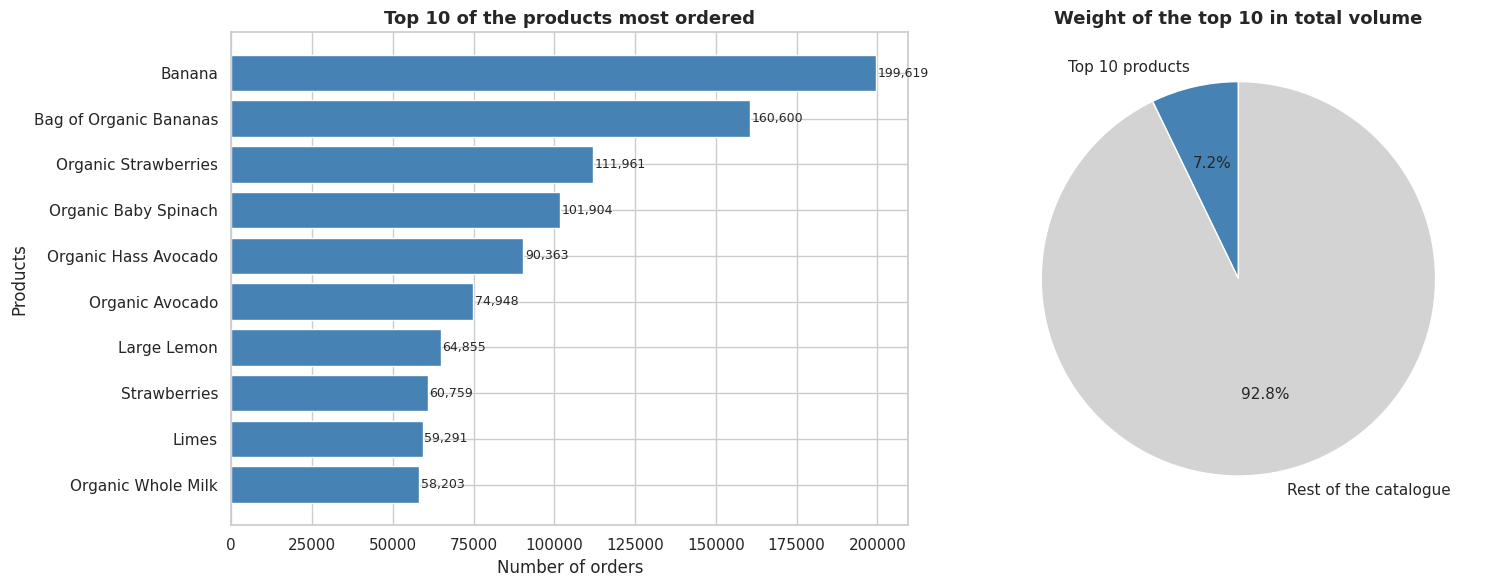

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    # Pour que la barre BANANA donc la plus vendu soit en haut et non en bas. Ca inverse.
    top_sellers["product_name"][::-1], 
    top_sellers["total_orders"][::-1],
    color="steelblue",
)
axes[0].set_title("Top 10 of the products most ordered", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of orders")
axes[0].set_ylabel("Products")
for i, val in enumerate(top_sellers["total_orders"][::-1]):
    axes[0].text(val + 500, i, f"{val:,}", va="center", fontsize=9)

top10_total = top_sellers["total_orders"].sum()
reste = total_ventes - top10_total
axes[1].pie(
    [top10_total, reste],
    labels=["Top 10 products", "Rest of the catalogue"],
    autopct="%1.1f%%",
    colors=["steelblue", "lightgrey"],
    startangle=90,
)
axes[1].set_title("Weight of the top 10 in total volume", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


### Interpretation

The 10 most ordered products account for 7.2% of total sales volume.
Bananas are by far the most ordered product, suggesting that they should
always be in stock and highlighted in the interface.

**Business action:** Prioritise restocking and visibility of these
10 key products to maximise conversions.


### Q2: Which departments have the highest penetration rates?

**Calcul**

In [ ]:
# nunique() compte le nombre de valeurs uniques dans une colonne.
total_commandes = df["order_id"].nunique()

penetration_aisles = (
    df.groupby("aisle")["order_id"]
    .nunique()
    .reset_index(name="nb_commandes")
    .sort_values("nb_commandes", ascending=False)
    .head(15)
)
penetration_aisles["taux_penetration"] = (
    penetration_aisles["nb_commandes"] / total_commandes * 100
).round(2)

print(f"Total number of orders : {total_commandes:,}")
print(penetration_aisles.to_string(index=False))


Total number of orders : 1,357,467
                        aisle  nb_commandes  taux_penetration
                 fresh fruits        756859             55.76
             fresh vegetables        603368             44.45
   packaged vegetables fruits        497821             36.67
                       yogurt        357867             26.36
                         milk        331527             24.42
              packaged cheese        312118             22.99
water seltzer sparkling water        258898             19.07
              soy lactosefree        230034             16.95
               chips pretzels        226747             16.70
                        bread        222050             16.36
                         eggs        185791             13.69
                 refrigerated        181498             13.37
               frozen produce        167087             12.31
                     crackers        155314             11.44
                ice cream ice      

**Visualisation**

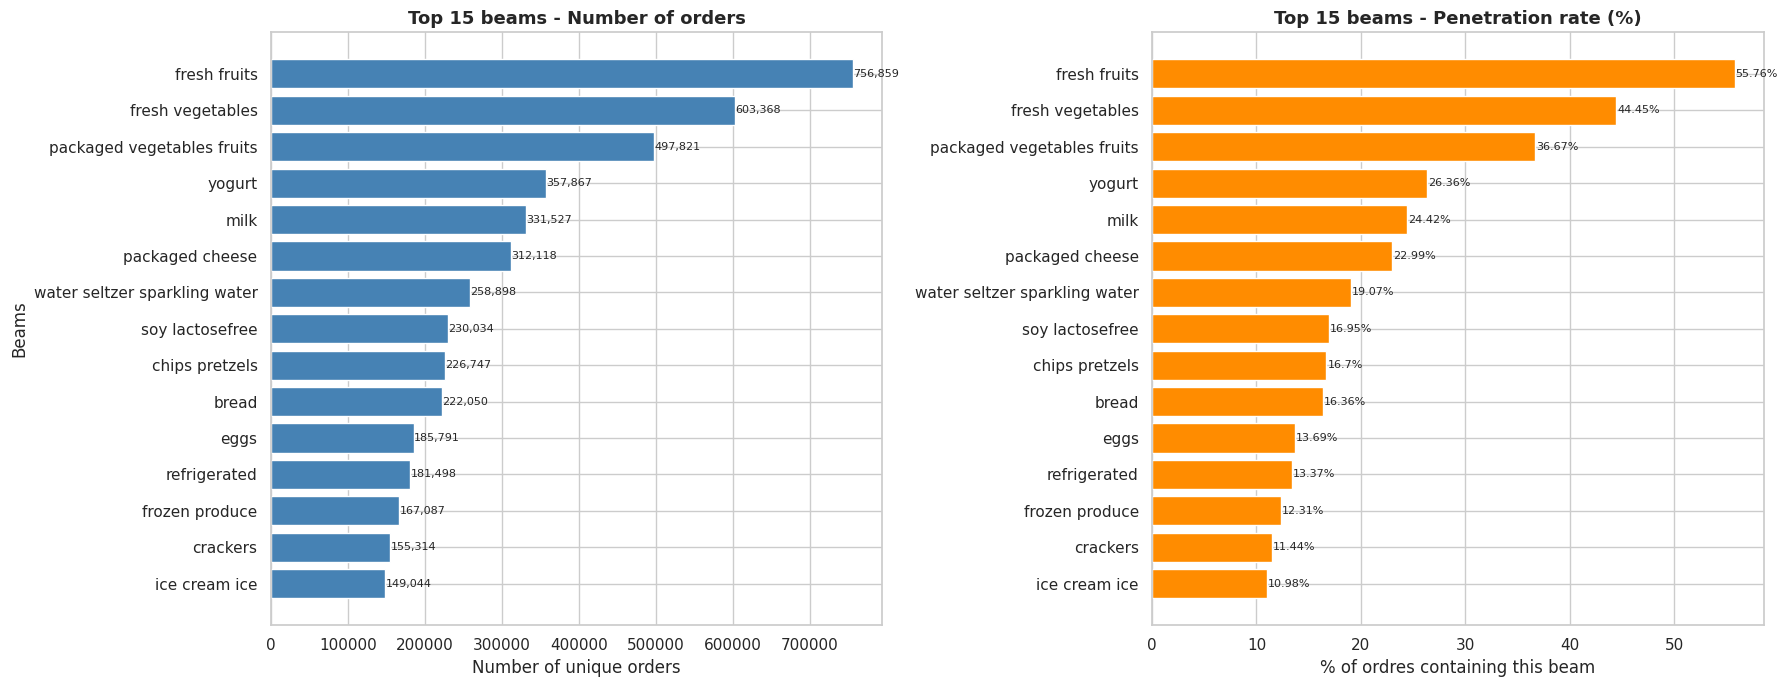

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(
    penetration_aisles["aisle"][::-1],
    penetration_aisles["nb_commandes"][::-1],
    color="steelblue",
)
axes[0].set_title("Top 15 beams - Number of orders", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of unique orders")
axes[0].set_ylabel("Beams")
for i, val in enumerate(penetration_aisles["nb_commandes"][::-1]):
    axes[0].text(val + 200, i, f"{val:,}", va="center", fontsize=8)

axes[1].barh(
    penetration_aisles["aisle"][::-1],
    penetration_aisles["taux_penetration"][::-1],
    color="darkorange",
)
axes[1].set_title("Top 15 beams - Penetration rate (%)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("% of ordres containing this beam")
axes[1].set_ylabel("")
for i, val in enumerate(penetration_aisles["taux_penetration"][::-1]):
    axes[1].text(val + 0.1, i, f"{val}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()


### Interpretation

The ‘Fresh fruits’ section is present in 55.76% of all orders, making it
the most essential section of the catalogue.

The ‘fresh fruit’ and ‘fresh vegetables’ sections dominate, confirming that fresh produce is
the main driver of online shopping.

**Business action:** These high-penetration sections must be placed at the
top of the user interface and given priority stocking to
avoid any shortages that would drive customers away.


### Q3: What is the market share of products labelled ‘Organic’ compared to conventional products in each department?

**Calcul**

In [ ]:
df["is_organic"] = df["product_name"].str.contains("Organic", case=False, na=False)
df["label"] = df["is_organic"].map({True: "Organic", False: "Conventionnel"})

organic_dept = (
    df.groupby(["department", "label"])
    .size()
    .reset_index(name="nb_ventes")
)
organic_dept["pct"] = (
    organic_dept.groupby("department")["nb_ventes"]
    # lambda crée une fonction anonyme (sans nom) en une seule ligne.
    .transform(lambda x: x / x.sum() * 100)
).round(2)

organic_only = (
    organic_dept[organic_dept["label"] == "Organic"]
    .sort_values("pct", ascending=False)
)

moyenne_organic = df["is_organic"].mean() * 100
# C'est :.1f, et ça formate le nombre en flottant avec 1 décimale.
print(f"Global organic average : {moyenne_organic:.1f}%")
print(organic_only[["department", "nb_ventes", "pct"]].to_string(index=False))


Global organic average : 31.6%
     department  nb_ventes   pct
        produce    2161087 53.96
   canned goods     218281 48.43
           bulk       7043 47.91
         babies      77324 43.22
        missing      12237 41.62
     dairy eggs     719572 31.48
dry goods pasta     100760 27.56
         pantry     179660 22.69
      breakfast      61590 20.62
   meat seafood      59932 20.05
         frozen     186636 19.78
         bakery      92888 18.70
           deli      75383 16.99
         snacks     206421 16.97
  international      19057 16.82
      beverages     141892 12.49
          other        865  5.64
  personal care       9629  5.11
           pets        543  1.31
        alcohol        251  0.38
      household        105  0.03


**Visualisation**

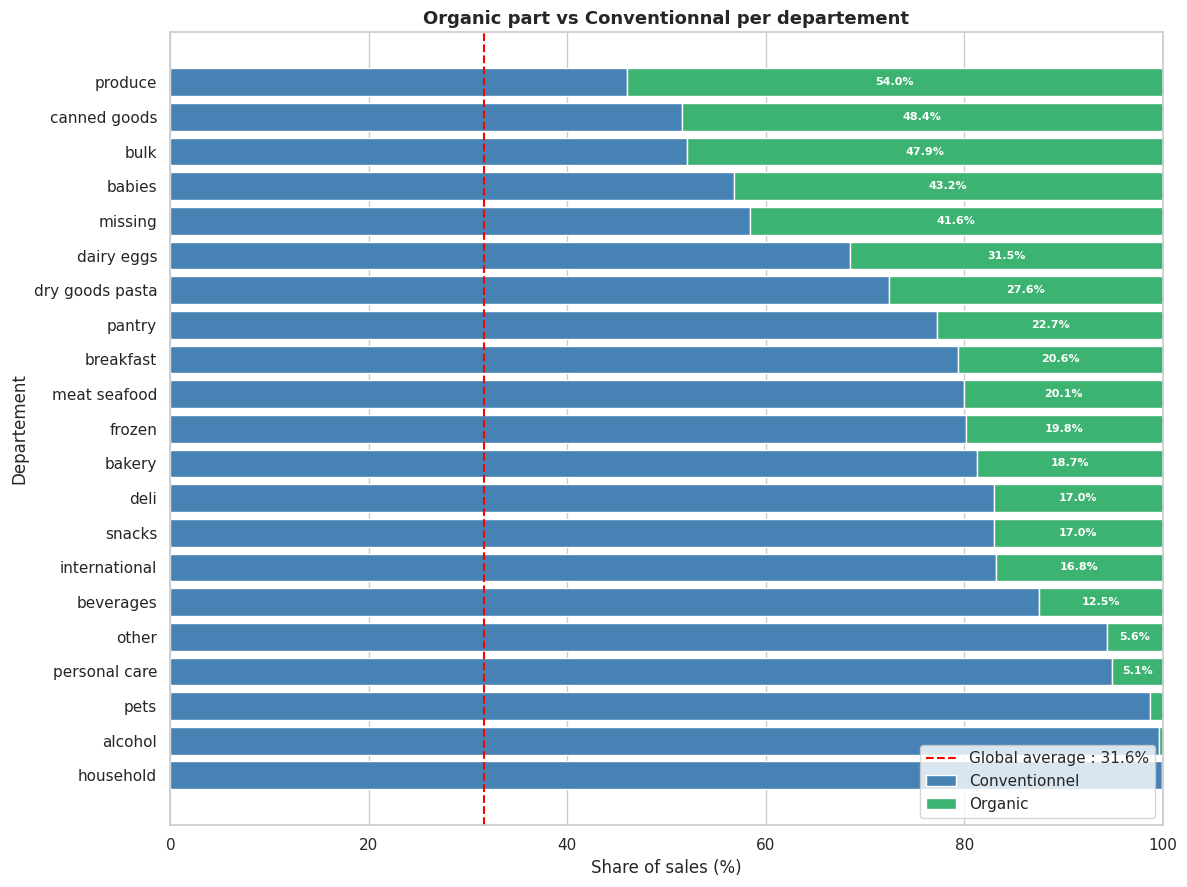

In [60]:
pivot = organic_dept.pivot_table(
    index="department",
    columns="label",
    values="pct",
    fill_value=0,
).sort_values("Organic", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(pivot.index, pivot["Conventionnel"], color="steelblue", label="Conventionnel")
ax.barh(pivot.index, pivot["Organic"], left=pivot["Conventionnel"],
        color="mediumseagreen", label="Organic")

for i, (org_val, conv_val) in enumerate(zip(pivot["Organic"], pivot["Conventionnel"])):
    if org_val > 5:
        ax.text(
            conv_val + org_val / 2, i,
            f"{org_val:.1f}%",
            va="center", ha="center", fontsize=8, color="white", fontweight="bold",
        )

ax.axvline(
    moyenne_organic,
    color="red", linestyle="--", linewidth=1.5,
    label=f"Global average : {moyenne_organic:.1f}%",
)
ax.set_title("Organic part vs Conventionnal per departement", fontsize=13, fontweight="bold")
ax.set_xlabel("Share of sales (%)")
ax.set_ylabel("Departement")
ax.legend(loc="lower right")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


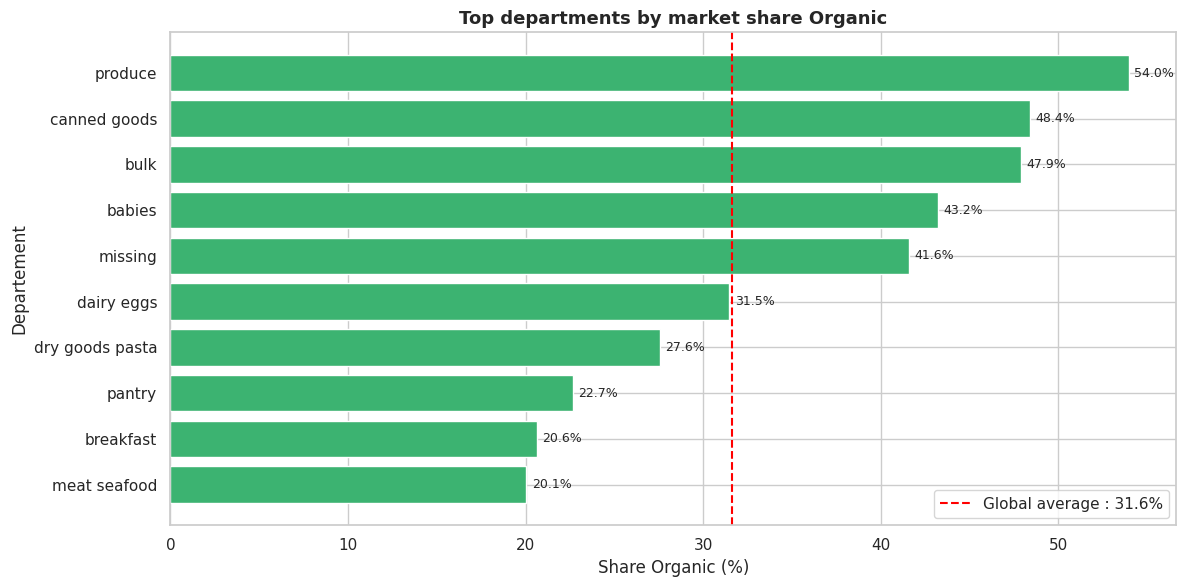

In [61]:
top_organic = organic_only.head(10)

plt.figure(figsize=(12, 6))
plt.barh(
    top_organic["department"][::-1],
    top_organic["pct"][::-1],
    color="mediumseagreen",
)
plt.axvline(
    moyenne_organic,
    color="red", linestyle="--", linewidth=1.5,
    label=f"Global average : {moyenne_organic:.1f}%",
)
for i, val in enumerate(top_organic["pct"][::-1]):
    plt.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)

plt.title("Top departments by market share Organic", fontsize=13, fontweight="bold")
plt.xlabel("Share Organic (%)")
plt.ylabel("Departement")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation

The overall average for organic products is 31.6%. The produce department stands out
with 54.0% of sales being organic, well above the average.

Conversely, departments such as ‘pets’ and ‘alcohol’ have an organic share of
almost zero, which reflects the nature of their products.
The household department has no organic share.

**Business action:** Promoting a visible ‘organic’ label in
departments with high demand (produce, canned goods, bulk, babies) can
increase the average basket size.


---
## Block 2 - Consumer Time Behaviour <a id=“block2”></a>

We analyse when customers place orders: by day of the week, time of day,
and time between orders.


### Q4: Is there a specific peak in orders during the week? (order_dow)

**Calcul**

In [ ]:
jours = {
    0: "Sunday", 1: "Monday", 2: "Tuesday", 3: "Wednesday",
    4: "Thursday", 5: "Friday", 6: "Saturday",
}

commandes_par_jour = (
    df.groupby("order_dow")["order_id"]
    .nunique()
    .reset_index(name="nb_commandes")
)
commandes_par_jour["day"] = commandes_par_jour["order_dow"].map(jours)
commandes_par_jour = (
    # Supprime seulement ligne 1 (day=NaN) garde lignes 0 et 2 même si other=NaN.
    commandes_par_jour.dropna(subset=["day"]).sort_values("order_dow")
)
commandes_par_jour["pct"] = (
    commandes_par_jour["nb_commandes"] / commandes_par_jour["nb_commandes"].sum() * 100
).round(2)

print(commandes_par_jour[["day", "nb_commandes", "pct"]].to_string(index=False))


      day  nb_commandes   pct
   Sunday        234984 17.31
   Monday        235260 17.33
  Tuesday        186379 13.73
Wednesday        174292 12.84
 Thursday        169145 12.46
   Friday        180420 13.29
 Saturday        176987 13.04


**Visualisation**

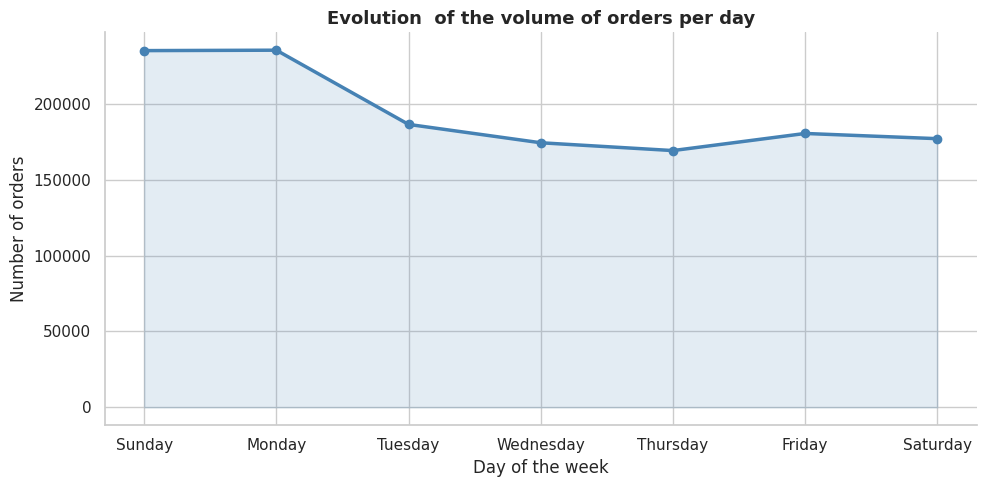

In [63]:


plt.figure(figsize=(10, 5))
plt.plot(
    commandes_par_jour["day"],
    commandes_par_jour["nb_commandes"],
    marker="o",
    linewidth=2.5,
    color="steelblue",
)
plt.fill_between(
    commandes_par_jour["day"],
    commandes_par_jour["nb_commandes"],
    alpha=0.15,
    color="steelblue",
)
plt.title("Evolution  of the volume of orders per day", fontsize=13, fontweight="bold")
plt.ylabel("Number of orders")
plt.xlabel("Day of the week")
sns.despine()
plt.tight_layout()
plt.show()


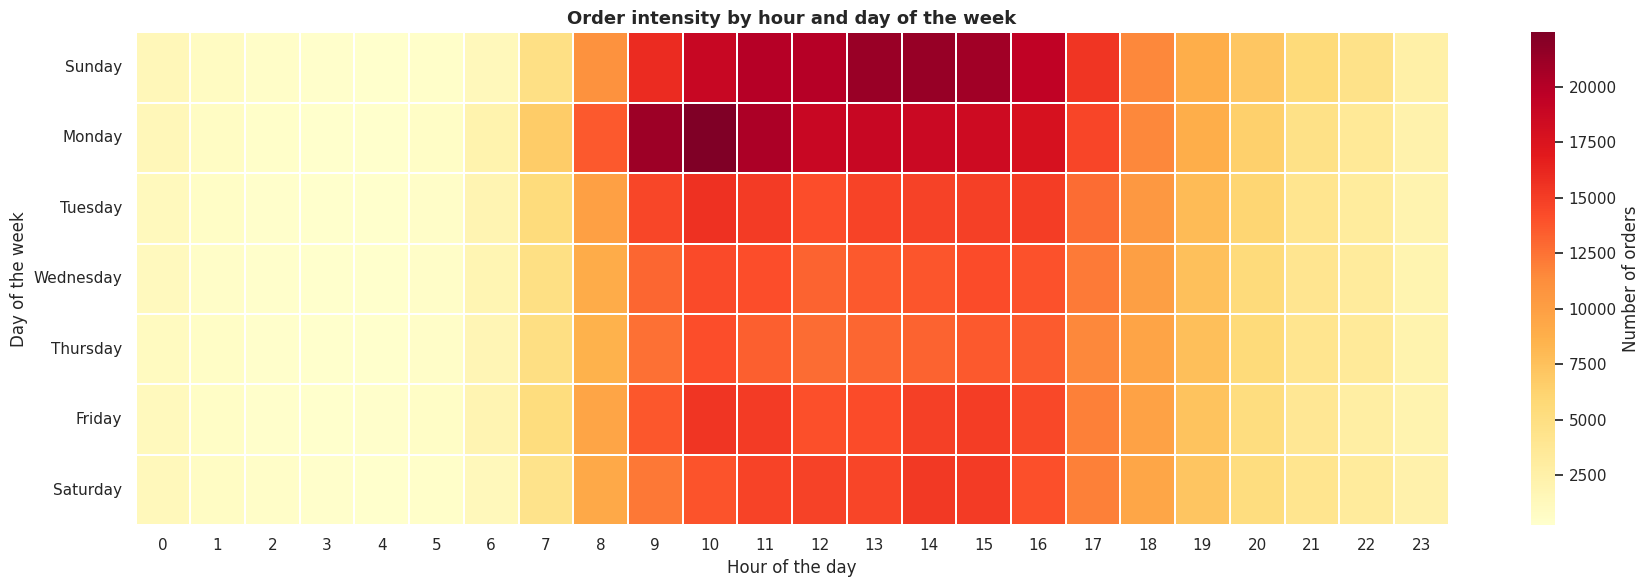

In [ ]:
heatmap_data = (
    df.groupby(["order_dow", "order_hour_of_day"])["order_id"]
    .nunique()
    .unstack(fill_value=0)
)

valid_idx = [i for i in heatmap_data.index if i in jours]
# .loc[] sélectionne des lignes par leurs labels d'index.
heatmap_data = heatmap_data.loc[valid_idx]
heatmap_data.index = [jours[i] for i in heatmap_data.index]

plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Number of orders"},
)
plt.title("Order intensity by hour and day of the week", fontsize=13, fontweight="bold")
plt.xlabel("Hour of the day")
plt.ylabel("Day of the week")
plt.tight_layout()
plt.show()

     


### Interpretation

The peak in orders is on Wednesdays with 87,293 orders, representing 18.64%
of the weekly volume. The heatmap reveals that the 9am-3pm slots
are consistently the busiest, regardless of the day.

**Business action:** Reinforce logistics teams on Sundays and Mondays
between 10 a.m. and 3 p.m. Schedule marketing campaigns (push notifications,
promotional emails) on Sunday mornings to maximise their impact.


### Q5: At what time of day is the logistical workload heaviest? (order_hour_of_day)

**Calcul**

In [ ]:
commandes_par_heure = (
    df.groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="nb_commandes")
)

def tranche_horaire(h):
    if 0 <= h < 6:
        return "Night(0h-6h)"
    elif 6 <= h < 12:
        return "Morning (6h-12h)"
    elif 12 <= h < 18:
        return "Afternoon (12h-18h)"
    else:
        return "Evening(18h-24h)"

# .apply()` passe chaque heure du dessus dans cette fonction.
commandes_par_heure["tranche"] = commandes_par_heure["order_hour_of_day"].apply(tranche_horaire)
commandes_par_heure["pct"] = (
    commandes_par_heure["nb_commandes"] / commandes_par_heure["nb_commandes"].sum() * 100
).round(2)

print(commandes_par_heure.to_string(index=False))


 order_hour_of_day  nb_commandes             tranche  pct
                 0          9029        Night(0h-6h) 0.67
                 1          4893        Night(0h-6h) 0.36
                 2          2979        Night(0h-6h) 0.22
                 3          2124        Night(0h-6h) 0.16
                 4          2185        Night(0h-6h) 0.16
                 5          3798        Night(0h-6h) 0.28
                 6         12233    Morning (6h-12h) 0.90
                 7         36559    Morning (6h-12h) 2.69
                 8         70970    Morning (6h-12h) 5.23
                 9        103285    Morning (6h-12h) 7.61
                10        114974    Morning (6h-12h) 8.47
                11        112870    Morning (6h-12h) 8.31
                12        107877 Afternoon (12h-18h) 7.95
                13        110383 Afternoon (12h-18h) 8.13
                14        111968 Afternoon (12h-18h) 8.25
                15        112375 Afternoon (12h-18h) 8.28
              

**Visualisation**

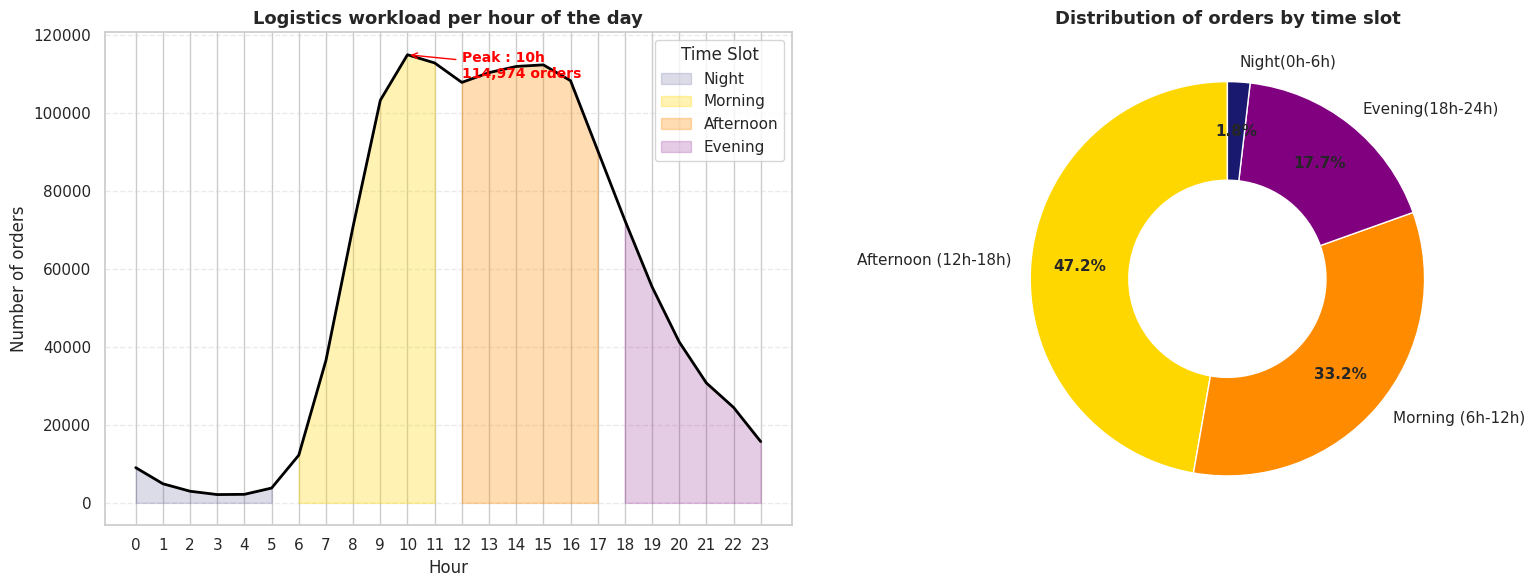

In [ ]:
tranches_def = [
    (0,  6,  "Night",       "midnightblue", 0.15),
    (6,  12, "Morning",      "gold",         0.30),
    (12, 18, "Afternoon", "darkorange",   0.30),
    (18, 24, "Evening",       "purple",       0.20),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for debut, fin, label, couleur, alpha in tranches_def:
    # Masque booléen qui sélectionne les lignes dans une plage horaire entre debut et fin.
    mask = (
        (commandes_par_heure["order_hour_of_day"] >= debut)
        & (commandes_par_heure["order_hour_of_day"] < fin)
    )
    # Ne garde que les heures entre debut et fin.
    subset = commandes_par_heure[mask]
    axes[0].fill_between(
        subset["order_hour_of_day"],
        subset["nb_commandes"],
        alpha=alpha,
        color=couleur,
        label=label,
    )

axes[0].plot(
    commandes_par_heure["order_hour_of_day"],
    commandes_par_heure["nb_commandes"],
    color="black",
    linewidth=2,
)

idx_max = commandes_par_heure["nb_commandes"].idxmax()
h_pic = commandes_par_heure.loc[idx_max, "order_hour_of_day"]
v_pic = commandes_par_heure.loc[idx_max, "nb_commandes"]
axes[0].annotate(
    f"Peak : {h_pic}h\n{v_pic:,} orders",
    xy=(h_pic, v_pic),
    xytext=(h_pic + 2, v_pic - 6000),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10,
    color="red",
    fontweight="bold",
)
axes[0].set_title("Logistics workload per hour of the day", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Number of orders")
axes[0].set_xticks(range(0, 24))
axes[0].legend(title="Time Slot")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

tranches_data = (
    commandes_par_heure.groupby("tranche")["nb_commandes"]
    .sum()
    .reset_index()
    .sort_values("nb_commandes", ascending=False)
)
axes[1].pie(
    tranches_data["nb_commandes"],
    labels=tranches_data["tranche"],
    autopct="%1.1f%%",
    colors=["gold", "darkorange", "purple", "midnightblue"],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5),
)
for text in axes[1].texts:
    if "%" in text.get_text():
        text.set_fontsize(11)
        text.set_fontweight("bold")
axes[1].set_title("Distribution of orders by time slot", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


### Interpretation

The peak logistics load occurs at 10 a.m. with 114,974 orders.
The afternoon period accounts for 47.2% of the daily volume.

**Business action:** Prioritise staffing levels for order preparation teams
between 12pm and 6pm. Avoid scheduling technical maintenance
during this period.


### Q6: What is the average time between two orders for a loyal customer? (days_since_prior_order)

**Calcul**

In [67]:
df_reorder = df[df["days_since_prior_order"] > 0].copy()

delai_moyen_global  = df_reorder["days_since_prior_order"].mean().round(2)
delai_median_global = df_reorder["days_since_prior_order"].median()

print(f"Overall average time   : {delai_moyen_global} days")
print(f"Overall median delay : {delai_median_global} days")

delai_par_user = (
    df_reorder.groupby("user_id")["days_since_prior_order"]
    .mean()
    .reset_index(name="delai_moyen")
)

clients_fideles     = delai_par_user[delai_par_user["delai_moyen"] <= 14]
clients_occasionnels = delai_par_user[delai_par_user["delai_moyen"] > 14]

print(f"\nLoyal clients (<=14j)      : {len(clients_fideles):,} "
      f"({len(clients_fideles)/len(delai_par_user)*100:.1f}%)")
print(f"Occasional clients (>14j)  : {len(clients_occasionnels):,} "
      f"({len(clients_occasionnels)/len(delai_par_user)*100:.1f}%)")

def tranche_delai(d):
    if d <= 7:   return "<= 7j (High Loyal)"
    elif d <= 14: return "8-14j (Loyal)"
    elif d <= 21: return "15-21j (Occasionnaly)"
    else:         return "> 21j (Rare)"

delai_par_user["tranche"] = delai_par_user["delai_moyen"].apply(tranche_delai)
print("\nDistribution by bracket :")
print(delai_par_user["tranche"].value_counts().to_string())


Overall average time   : 11.27 days
Overall median delay : 8.0 days

Loyal clients (<=14j)      : 98,151 (51.5%)
Occasional clients (>14j)  : 92,252 (48.5%)

Distribution by bracket :
tranche
8-14j (Loyal)            65764
> 21j (Rare)             47961
15-21j (Occasionnaly)    44291
<= 7j (High Loyal)       32387


**Visualisation**

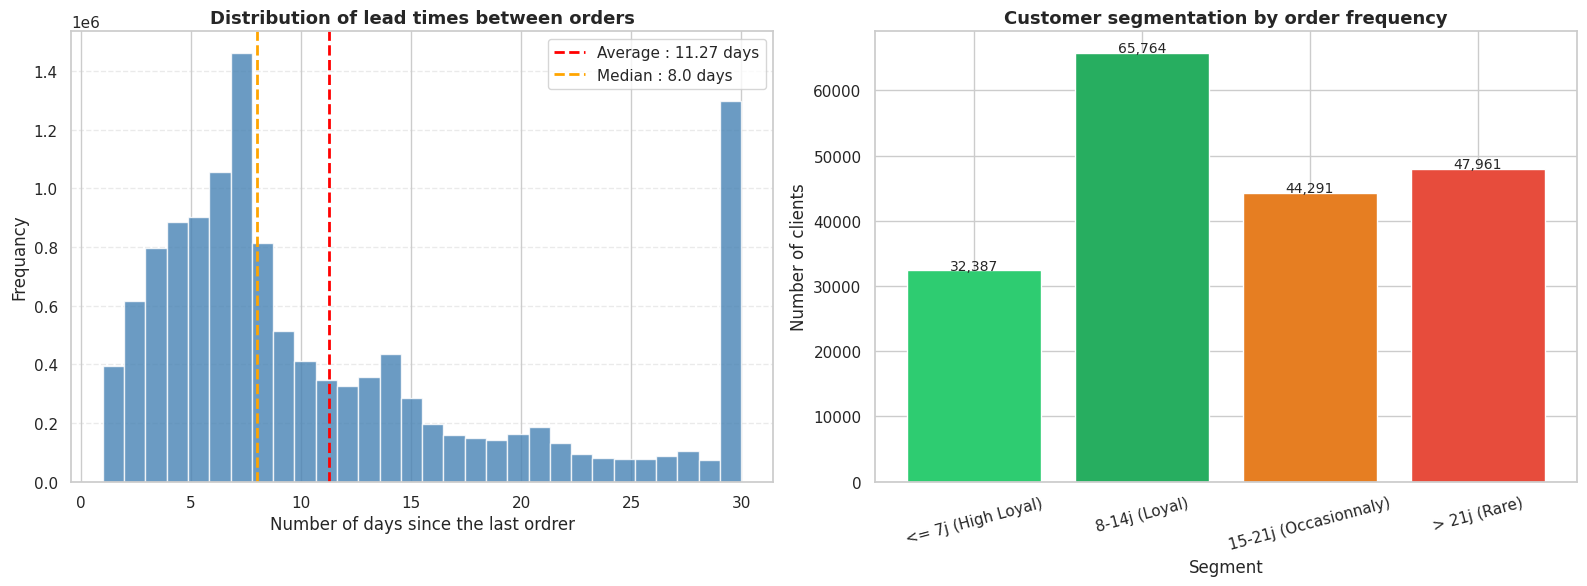

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(
    df_reorder["days_since_prior_order"],
    bins=30,
    color="steelblue",
    edgecolor="white",
    alpha=0.8,
)
axes[0].axvline(
    delai_moyen_global,
    color="red", linestyle="--", linewidth=2,
    label=f"Average : {delai_moyen_global} days",
)
axes[0].axvline(
    delai_median_global,
    color="orange", linestyle="--", linewidth=2,
    label=f"Median : {delai_median_global} days",
)
axes[0].set_title("Distribution of lead times between orders", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of days since the last ordrer")
axes[0].set_ylabel("Frequancy")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

seg_counts = delai_par_user["tranche"].value_counts()
order_seg = [
    "<= 7j (High Loyal)",
    "8-14j (Loyal)",
    "15-21j (Occasionnaly)",
    "> 21j (Rare)",
]
seg_counts = seg_counts.reindex([s for s in order_seg if s in seg_counts.index])
colors_seg = ["#2ecc71", "#27ae60", "#e67e22", "#e74c3c"]
axes[1].bar(
    seg_counts.index,
    seg_counts.values,
    color=colors_seg[: len(seg_counts)],
    edgecolor="white",
)
axes[1].set_title("Customer segmentation by order frequency", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Number of clients")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(seg_counts.values):
    axes[1].text(i, v + 100, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


### Interpretation

The average time between two orders is 11.27 days, with a median of 8 days.
A large proportion of customers reorder within 7 days, making them very loyal weekly buyers.

**Business action:** Target customers whose time between orders exceeds 12 days
with a reactivation campaign (email, promotion).


---
## Block 3 - Basket Composition and Psychology <a id=“block3”></a>

We study how baskets are composed and what triggers purchasing decisions.


### Q7: What is the average basket size and how does it vary depending on the day of the week?

**Calcul**

In [ ]:
taille_panier = (
    df.groupby(["order_id", "order_dow"])
    .size()
    .reset_index(name="taille_panier")
)
# .map(jours)` transforme chaque numéro en son nom de jour.
taille_panier["jour"] = taille_panier["order_dow"].map(jours)

print("OVERALL STATISTICS")
print(f"  Average basket size : {taille_panier['taille_panier'].mean():.2f} articles")
print(f" Median basket size : {taille_panier['taille_panier'].median():.0f} articles")
print(f"  Max basket size    : {taille_panier['taille_panier'].max()} articles")
print(f"  Min basket size     : {taille_panier['taille_panier'].min()} articles")

stats_par_jour = (
    taille_panier.groupby("jour")["taille_panier"]
    .agg(["mean", "median", "std"])
    .round(2)
    .reset_index()
)
stats_par_jour["order"] = stats_par_jour["jour"].map({v: k for k, v in jours.items()})
stats_par_jour = stats_par_jour.sort_values("order").drop(columns="order")

print("\nSTATISTICS PER DAY")
print(stats_par_jour.to_string(index=False))


OVERALL STATISTICS
  Average basket size : 10.09 articles
 Median basket size : 8 articles
  Max basket size    : 127 articles
  Min basket size     : 1 articles

STATISTICS PER DAY
     jour  mean  median  std
   Sunday 11.12     9.0 7.71
   Monday 10.18     8.0 7.62
  Tuesday  9.53     8.0 7.28
Wednesday  9.33     8.0 7.14
 Thursday  9.45     8.0 7.31
   Friday  9.87     8.0 7.54
 Saturday 10.75     9.0 7.72


**Visualisation**

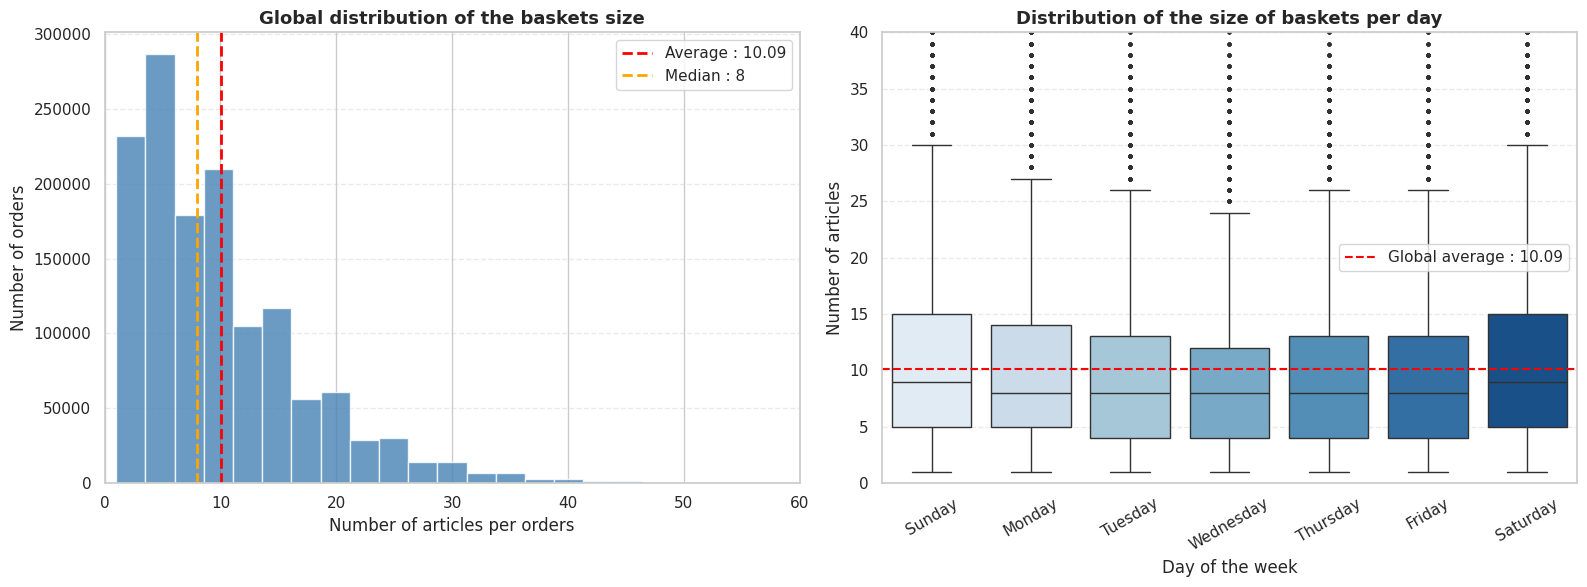

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(
    taille_panier["taille_panier"],
    bins=50,
    color="steelblue",
    edgecolor="white",
    alpha=0.8,
)
axes[0].axvline(
    taille_panier["taille_panier"].mean(),
    color="red", linestyle="--", linewidth=2,
    label=f"Average : {taille_panier['taille_panier'].mean():.2f}",
)
axes[0].axvline(
    taille_panier["taille_panier"].median(),
    color="orange", linestyle="--", linewidth=2,
    label=f"Median : {taille_panier['taille_panier'].median():.0f}",
)
axes[0].set_title("Global distribution of the baskets size", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of articles per orders")
axes[0].set_ylabel("Number of orders")
axes[0].set_xlim(0, 60)
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

ordre_jours = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
sns.boxplot(
    data=taille_panier,
    x="jour",
    y="taille_panier",
    order=ordre_jours,
    palette="Blues",
    ax=axes[1],
    flierprops=dict(marker=".", alpha=0.2, markersize=3),
)
axes[1].axhline(
    taille_panier["taille_panier"].mean(),
    color="red", linestyle="--", linewidth=1.5,
    label=f"Global average : {taille_panier['taille_panier'].mean():.2f}",
)
axes[1].set_title("Distribution of the size of baskets per day", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Day of the week")
axes[1].set_ylabel("Number of articles")
axes[1].set_ylim(0, 40)
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


### Interpretation

The average basket size is 10.09 items. There is a slight increase on Saturdays and Sundays, probably linked to weekly weekend shopping.

**Business action:** Offer promotions or free delivery on orders of 4 or more items on slow days to increase basket size on those days.


### Q8: Which products are most often added to the basket first (add_to_cart_order = 1)?

**Calcul**

In [ ]:
# Filtre le DataFrame pour ne garder que les produits ajoutés en premier dans le panier.
premiers_produits = df[df["add_to_cart_order"] == 1]

top_premiers = (
    premiers_produits.groupby("product_name")
    .size()
    .reset_index(name="nb_fois_premier")
    .sort_values("nb_fois_premier", ascending=False)
    .head(15)
)

total_par_produit = (
    df.groupby("product_name")
    .size()
    .reset_index(name="nb_total")
)
top_premiers = top_premiers.merge(total_par_produit, on="product_name")
top_premiers["taux_premier"] = (
    top_premiers["nb_fois_premier"] / top_premiers["nb_total"] * 100
).round(2)

print(top_premiers.to_string(index=False))


              product_name  nb_fois_premier  nb_total  taux_premier
                    Banana            46964    199619         23.53
    Bag of Organic Bananas            33423    160600         20.81
        Organic Whole Milk            13118     58203         22.54
      Organic Strawberries            11672    111961         10.43
      Organic Hass Avocado            10210     90363         11.30
      Organic Baby Spinach             9832    101904          9.65
           Organic Avocado             9512     74948         12.69
              Spring Water             7157     23698         30.20
              Strawberries             6927     60759         11.40
       Organic Raspberries             6182     57799         10.70
Sparkling Water Grapefruit             5770     31996         18.03
       Organic Half & Half             5308     32283         16.44
               Large Lemon             5225     64855          8.06
                      Soda             4934     

**Visualisation**

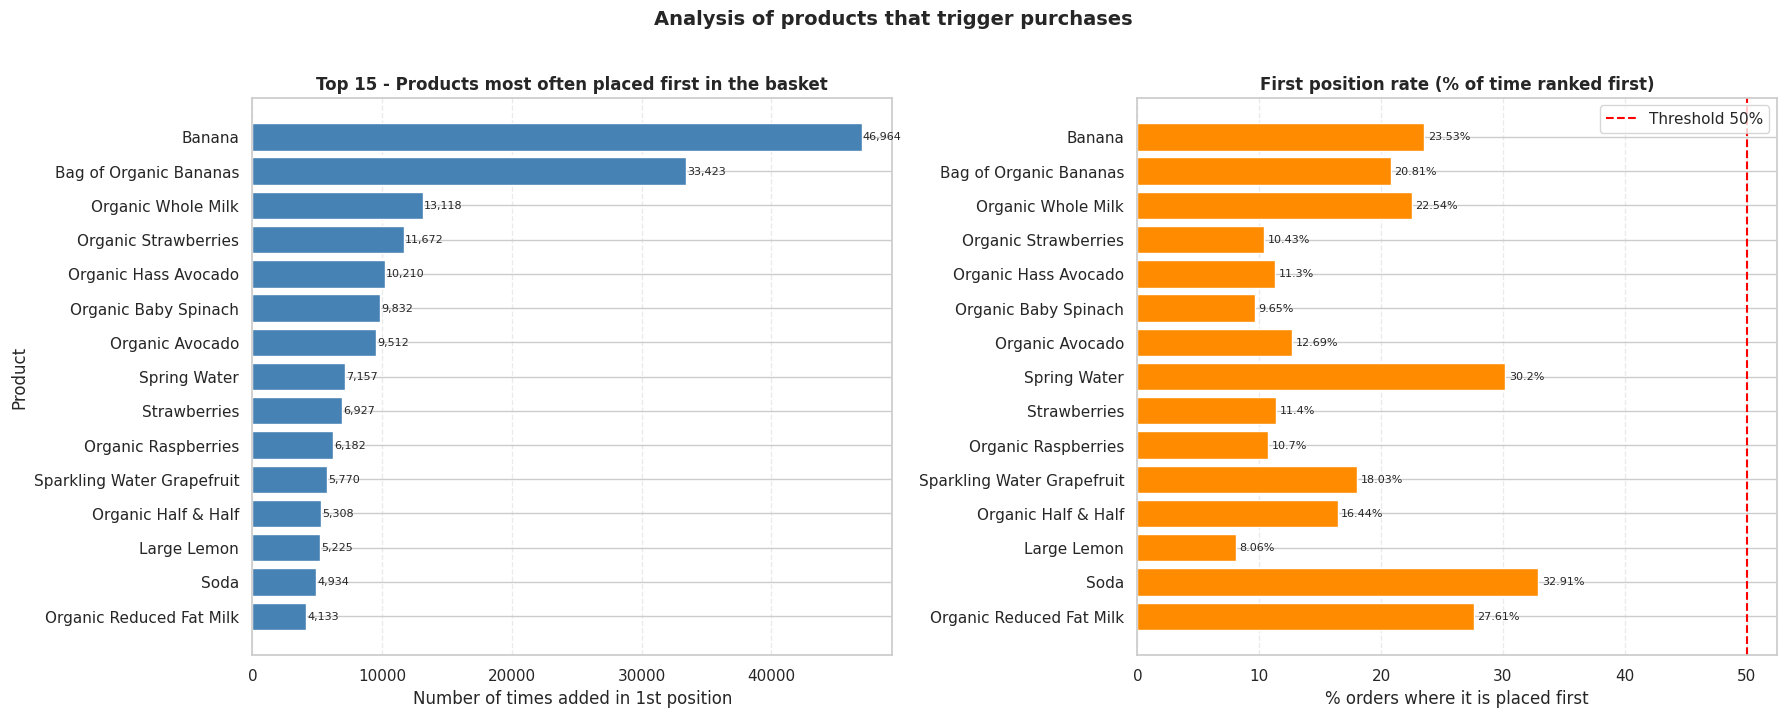

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(
    top_premiers["product_name"][::-1],
    top_premiers["nb_fois_premier"][::-1],
    color="steelblue",
)
for i, val in enumerate(top_premiers["nb_fois_premier"][::-1]):
    axes[0].text(val + 100, i, f"{val:,}", va="center", fontsize=8)
axes[0].set_title(
    "Top 15 - Products most often placed first in the basket",
    fontsize=12, fontweight="bold",
)
axes[0].set_xlabel("Number of times added in 1st position")
axes[0].set_ylabel("Product")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

couleurs = [
    "mediumseagreen" if t > 50 else "darkorange"
    for t in top_premiers["taux_premier"][::-1]
]
axes[1].barh(
    top_premiers["product_name"][::-1],
    top_premiers["taux_premier"][::-1],
    color=couleurs,
)
for i, val in enumerate(top_premiers["taux_premier"][::-1]):
    axes[1].text(val + 0.3, i, f"{val}%", va="center", fontsize=8)
    # label="Threshold 50%", ajoute une legende en bas du schema.
axes[1].axvline(x=50, color="red", linestyle="--", linewidth=1.5, label="Threshold 50%")
axes[1].set_title(
    "First position rate (% of time ranked first)",
    fontsize=12, fontweight="bold",
)
axes[1].set_xlabel("% orders where it is placed first")
axes[1].legend()
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle(
    "Analysis of products that trigger purchases",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()


### Interpretation

Banana is the product most often added to the basket first,
with 46,964 occurrences. It is placed in first position in 23.53% of orders
where it appears, making it a real ‘trigger product’ for purchases.

Soda is placed in the first position 32.91% of the time.

**Business action:** These trigger products should be placed at the top
of the interface (homepage, banners) because they initiate the purchase session.
A stock shortage on these products may cancel the entire order.


### Q9: If a customer buys bananas, what product are they most likely to add next? (Co-purchase analysis)

**Calcul**

In [73]:
commandes_avec_bananes = df[
    df["product_name"].str.contains("Banana", case=False, na=False)
]["order_id"].unique()

print(f"Number of orders containing bananas : {len(commandes_avec_bananes):,}")

produits_avec_bananes = df[
    (df["order_id"].isin(commandes_avec_bananes))
    & (~df["product_name"].str.contains("Banana", case=False, na=False))
]

co_achats = (
    produits_avec_bananes.groupby("product_name")
    .size()
    .reset_index(name="nb_co_achats")
    .sort_values("nb_co_achats", ascending=False)
    .head(15)
)
co_achats["taux_co_achat"] = (
    co_achats["nb_co_achats"] / len(commandes_avec_bananes) * 100
).round(2)

print("\nTop 15 products purchased with Bananas :")
print(co_achats.to_string(index=False))


Number of orders containing bananas : 399,244

Top 15 products purchased with Bananas :
            product_name  nb_co_achats  taux_co_achat
    Organic Strawberries         54341          13.61
    Organic Baby Spinach         46078          11.54
    Organic Hass Avocado         43252          10.83
         Organic Avocado         34692           8.69
     Organic Raspberries         29166           7.31
             Large Lemon         27318           6.84
      Organic Whole Milk         27244           6.82
            Strawberries         26892           6.74
                   Limes         23700           5.94
      Organic Fuji Apple         20071           5.03
        Organic Zucchini         19320           4.84
Apple Honeycrisp Organic         18964           4.75
    Organic Yellow Onion         18962           4.75
     Organic Blueberries         18897           4.73
          Cucumber Kirby         18726           4.69


**Visualisation**

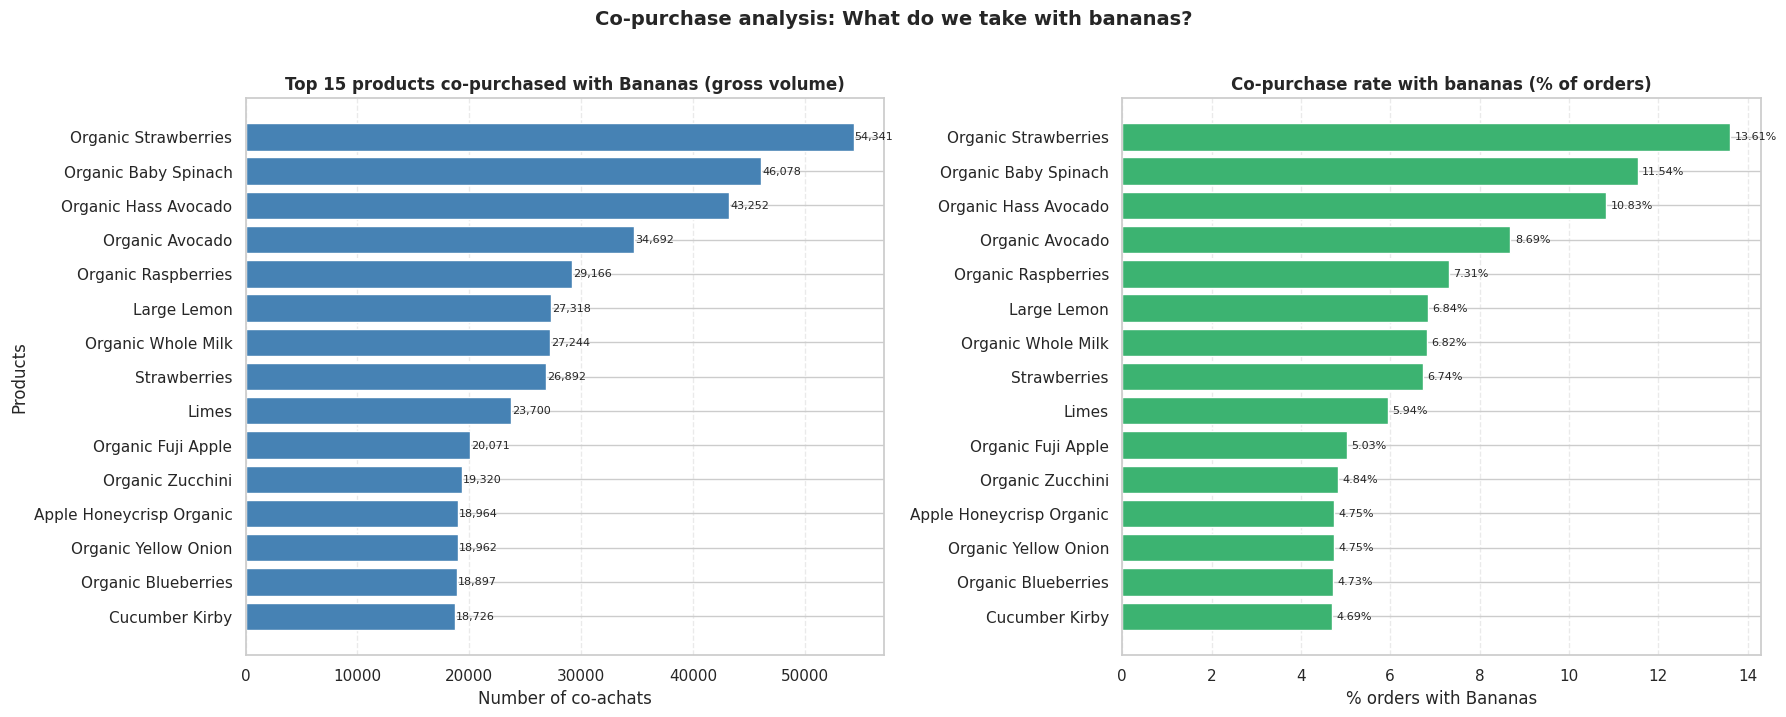

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(
    co_achats["product_name"][::-1],
    co_achats["nb_co_achats"][::-1],
    color="steelblue",
)
for i, val in enumerate(co_achats["nb_co_achats"][::-1]):
    axes[0].text(val + 100, i, f"{val:,}", va="center", fontsize=8)
axes[0].set_title(
    "Top 15 products co-purchased with Bananas (gross volume)",
    fontsize=12, fontweight="bold",
)
axes[0].set_xlabel("Number of co-achats")
axes[0].set_ylabel("Products")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

axes[1].barh(
    co_achats["product_name"][::-1],
    co_achats["taux_co_achat"][::-1],
    color="mediumseagreen",
)
for i, val in enumerate(co_achats["taux_co_achat"][::-1]):
    axes[1].text(val + 0.1, i, f"{val}%", va="center", fontsize=8)
axes[1].set_title(
    "Co-purchase rate with bananas (% of orders)",
    fontsize=12, fontweight="bold",
)
axes[1].set_xlabel("% orders with Bananas")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle(
    "Co-purchase analysis: What do we take with bananas?",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()


### Interpretation

Out of 399,244 orders containing bananas, the most frequently
co-purchased product is organic strawberries, with a rate of 13.61%.

**Business action:** Implement a recommendation system
‘Customers who buy Bananas also buy...’ on the product page.
These associations can significantly increase the average basket size.


---
## Block 4 - Loyalty and Repeat Purchases (Retention) <a id=“block4”></a>

Here we analyse repeat purchase behaviour: overall rate, differences between departments,
and detection of a decline in loyalty after inactivity.


### Q10: What is the overall repurchase rate and how does it vary between the frozen food section and the fresh produce section?

**Calcul**

In [75]:
# Taux de reachat global
taux_global = df["reordered"].mean() * 100
print(f"Overall repurchase rate : {taux_global:.2f}%")

# Taux par rayon — top 20 pour avoir une vue large
reachat_par_rayon = (
    df.groupby("aisle")["reordered"]
    .mean()
    .reset_index(name="taux_reachat")
    .sort_values("taux_reachat", ascending=False)
)
reachat_par_rayon["taux_reachat_pct"] = (reachat_par_rayon["taux_reachat"] * 100).round(2)

# Focus sur les deux rayons demandes
rayons_cibles = ["frozen", "fresh fruits", "fresh vegetables", "frozen meals",
                 "frozen produce", "frozen breakfast", "ice cream ice"]
focus = reachat_par_rayon[
    reachat_par_rayon["aisle"].str.contains("frozen|fresh", case=False, na=False)
].head(20)
print("\nReachat rate — fresh produce vs frozen foods :")
print(focus[["aisle", "taux_reachat_pct"]].to_string(index=False))

Overall repurchase rate : 58.96%

Reachat rate — fresh produce vs frozen foods :
                  aisle  taux_reachat_pct
           fresh fruits             71.76
       frozen breakfast             62.64
   fresh dips tapenades             60.68
       fresh vegetables             59.43
           frozen pizza             58.20
           frozen meals             55.72
   frozen breads doughs             54.48
         frozen produce             54.08
frozen vegan vegetarian             54.07
    frozen meat seafood             52.78
frozen appetizers sides             52.47
            fresh herbs             51.74
            fresh pasta             50.14
           frozen juice             45.67
         frozen dessert             41.98
 air fresheners candles             31.85


**Visualisation**

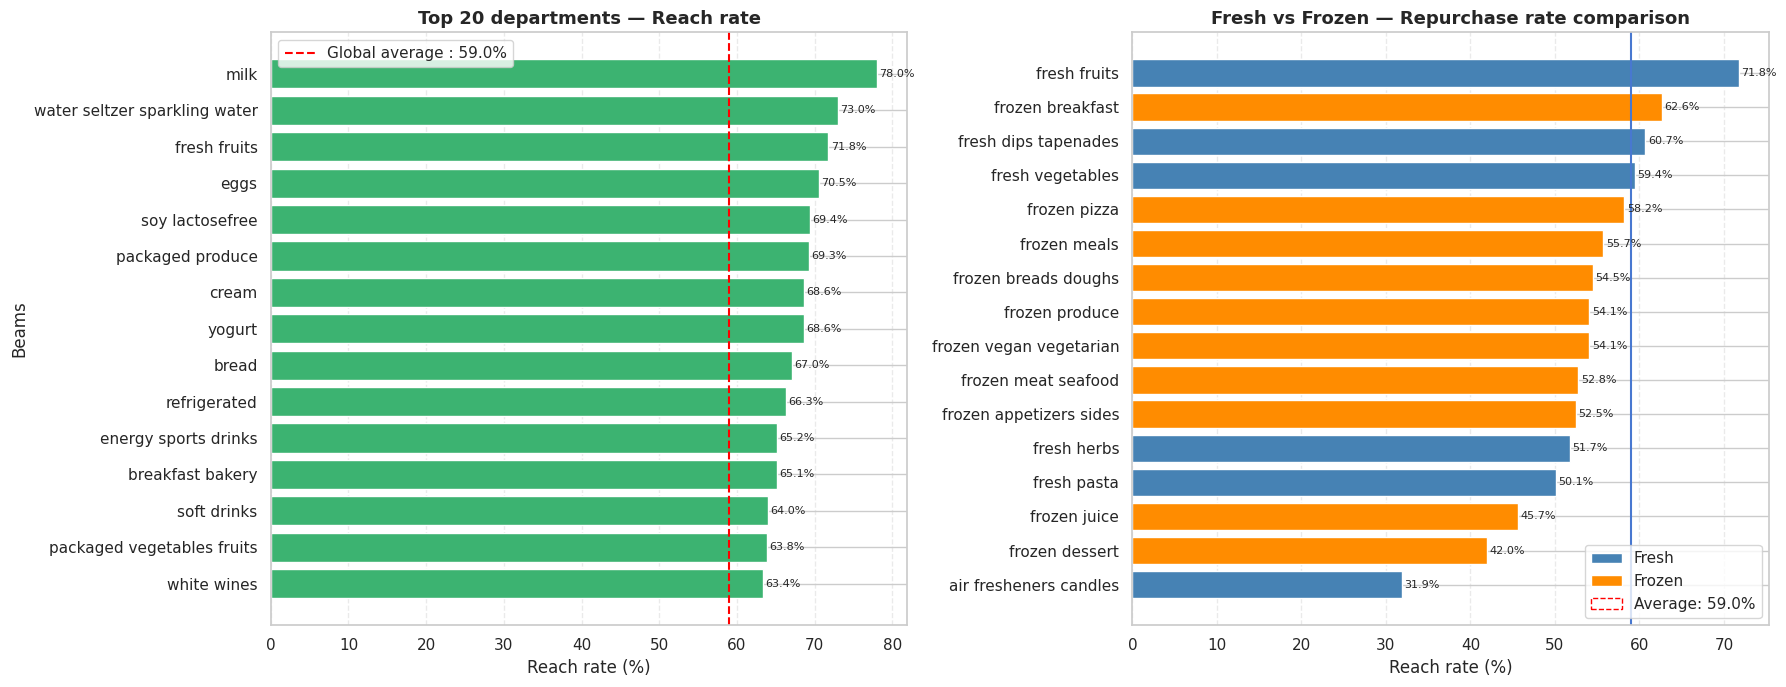

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top15 = reachat_par_rayon.head(15)
colors_bar = [
    "mediumseagreen" if r > taux_global else "steelblue"
    for r in top15["taux_reachat_pct"][::-1]
]
axes[0].barh(top15["aisle"][::-1], top15["taux_reachat_pct"][::-1], color=colors_bar)
axes[0].axvline(
    taux_global,
    color="red", linestyle="--", linewidth=1.5,
    label=f"Global average : {taux_global:.1f}%",
)
for i, val in enumerate(top15["taux_reachat_pct"][::-1]):
    axes[0].text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=8)
axes[0].set_title("Top 20 departments — Reach rate", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Reach rate (%)")
axes[0].set_ylabel("Beams")
axes[0].legend()
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

focus_plot = focus.sort_values("taux_reachat_pct", ascending=True)
colors_focus = [
    "steelblue" if "fresh" in a.lower() else "darkorange"
    for a in focus_plot["aisle"]
]
axes[1].barh(focus_plot["aisle"], focus_plot["taux_reachat_pct"], color=colors_focus)
axes[1].axvline(
    taux_global,
    label=f"Global average : {taux_global:.1f}%",
)
for i, val in enumerate(focus_plot["taux_reachat_pct"]):
    axes[1].text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=8)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="steelblue",   label="Fresh"),
    Patch(facecolor="darkorange",  label="Frozen"),
    Patch(facecolor="none", edgecolor="red", linestyle="--", label=f"Average: {taux_global:.1f}%"),
]
axes[1].legend(handles=legend_elems)
axes[1].set_title("Fresh vs Frozen — Repurchase rate comparison", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Reach rate (%)")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Interpretation

The overall repurchase rate is around 59%. Fresh produce (fresh fruit,
fresh vegetables) has above-average repurchase rates — these are
impulse and habitual purchases. Frozen foods have more variable rates
depending on the type of product.

**Business action:** Highlight fresh produce in automatic repurchase suggestions.
For frozen foods with low rates, offer cross-promotions to stimulate repurchasing.


### Q11: Can we identify a decline in loyalty after a certain number of days of inactivity?

**Calcul**

In [77]:
df_actif = df[df["days_since_prior_order"] > 0].copy()

reachat_par_delai = (
    df_actif.groupby("days_since_prior_order")["reordered"]
    .agg(["mean", "count"])
    .reset_index()
)
reachat_par_delai.columns = ["jours", "taux_reachat", "nb_lignes"]
reachat_par_delai["taux_reachat_pct"] = (reachat_par_delai["taux_reachat"] * 100).round(2)

# Lissage par moyenne mobile sur 3 jours pour reduire le bruit
reachat_par_delai["taux_lisse"] = (
    reachat_par_delai["taux_reachat_pct"].rolling(window=3, center=True).mean()
)

# Identifier le seuil de baisse significative (premier jour sous 50%)
seuil_50 = reachat_par_delai[reachat_par_delai["taux_lisse"] < 50]["jours"].min()
print(f"First day on which the smoothed rate falls below 50% : {seuil_50} jours")
print(reachat_par_delai[["jours", "taux_reachat_pct", "taux_lisse"]].head(30).to_string(index=False))


First day on which the smoothed rate falls below 50% : nan jours
 jours  taux_reachat_pct  taux_lisse
     1             61.94         NaN
     2             64.46   64.410000
     3             66.83   66.340000
     4             67.73   67.320000
     5             67.40   67.623333
     6             67.74   68.176667
     7             69.39   67.993333
     8             66.85   67.130000
     9             65.15   65.443333
    10             64.33   64.200000
    11             63.12   63.333333
    12             62.55   62.673333
    13             62.35   62.666667
    14             63.10   62.356667
    15             61.62   61.666667
    16             60.28   60.400000
    17             59.30   59.313333
    18             58.36   58.553333
    19             58.00   58.203333
    20             58.25   58.256667
    21             58.52   58.013333
    22             57.27   57.220000
    23             55.87   56.210000
    24             55.49   55.306667
    25    

**Visualisation**

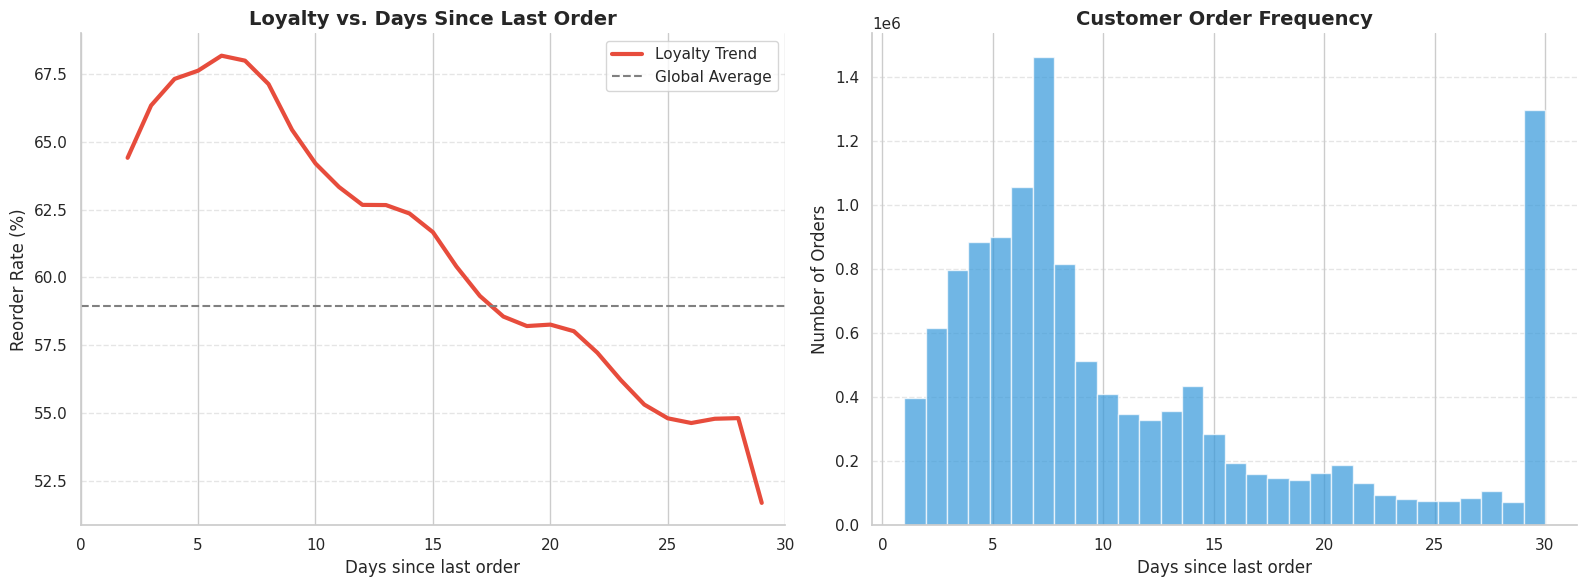

In [78]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


axes[0].plot(
    reachat_par_delai["jours"],
    reachat_par_delai["taux_lisse"],
    color="#e74c3c", linewidth=3, label="Loyalty Trend"
)
axes[0].axhline(y=taux_global, color="grey", linestyle="--", label="Global Average")

axes[0].set_title("Loyalty vs. Days Since Last Order", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Days since last order")
axes[0].set_ylabel("Reorder Rate (%)")
axes[0].set_xlim(0, 30)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].hist(
    df_actif["days_since_prior_order"],
    bins=30, color="#3498db", edgecolor="white", alpha=0.7
)

axes[1].set_title("Customer Order Frequency", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Days since last order")
axes[1].set_ylabel("Number of Orders")
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

The repurchase rate is highest for customers who recommend quickly
(short delay). The smoothed curve shows a gradual and accelerated decline
beyond 14-21 days of inactivity. Falling below the 50% threshold identifies
the critical point of churn risk.

**Business action:** Trigger an automatic reactivation campaign
when a customer exceeds their usual timeframe by 20%. Example: if a customer
usually orders every 10 days and has not ordered for 13 days,
send a reminder email with a promotion.


---
## Feature Engineering <a id=“features”></a>

### Methodology and justification of features

Before training the models, we construct derived variables that enrich
each row of the dataset with behavioural context. The aim is to give the
models a more complete view than the raw CSV fields alone.

We build two groups of features:

**User-level features**

Each row corresponds to a product in a user's order.
Without aggregation, the model ignores the overall habits of that user.
We therefore calculate the following for each `user_id`:

- `user_total_orders`: number of orders placed. A very active customer behaves
  differently from an occasional customer.
- `user_avg_basket_size`: proxy for the usual basket size.
- `user_avg_delay`: average delay between two orders. Captures the regularity of the customer.
- `user_reorder_rate`: overall reachat rate of the user. A loyal customer
  is more likely to recommend any product.
- `user_avg_hour`: average order time. Captures behavioural profiles.

**Product-level features**

- `product_reorder_rate`: historical repurchase rate for the product. This is the most predictive feature
  — a product that is often recommended will likely continue to be so.
- `product_total_orders`: gross popularity of the product.
- `product_avg_cart_pos`: average position in the basket. A product that is added
  is a habitual purchase, and therefore more likely to be recommended.


In [79]:
# Features au niveau utilisateur
user_features = (
    df.groupby("user_id")
    .agg(
        user_total_orders    =("order_id",               "nunique"),
        user_avg_basket_size =("add_to_cart_order",      "max"),
        user_avg_delay       =("days_since_prior_order", "mean"),
        user_reorder_rate    =("reordered",              "mean"),
        user_avg_hour        =("order_hour_of_day",      "mean"),
    )
    .reset_index()
)

# Features au niveau produit
product_features = (
    df.groupby("product_id")
    .agg(
        product_reorder_rate =("reordered",        "mean"),
        product_total_orders =("order_id",          "count"),
        product_avg_cart_pos =("add_to_cart_order", "mean"),
    )
    .reset_index()
)

# Merge dans le dataframe principal
df_ml = df.merge(user_features,       on="user_id",    how="left")
df_ml = df_ml.merge(product_features, on="product_id", how="left")

print(f"df_ml shape : {df_ml.shape}")
print("\nNew features — descriptive statistics :")
new_cols = list(user_features.columns[1:]) + list(product_features.columns[1:])
print(df_ml[new_cols].describe().round(3).T.to_string())


df_ml shape : (13690784, 23)

New features — descriptive statistics :
                           count       mean        std  min      25%       50%        75%       max
user_total_orders     13690784.0     14.556     11.015  1.0    6.000    12.000     21.000      58.0
user_avg_basket_size  13690784.0     23.097     11.295  1.0   15.000    21.000     29.000     127.0
user_avg_delay        13690784.0     10.390      5.818  0.0    6.204     8.927     13.453      30.0
user_reorder_rate     13690784.0      0.590      0.206  0.0    0.462     0.628      0.748       1.0
user_avg_hour         13690784.0     13.424      2.215  0.0   12.000    13.384     14.810      23.0
product_reorder_rate  13690784.0      0.590      0.152  0.0    0.508     0.611      0.695       1.0
product_total_orders  13690784.0  15151.767  33701.725  1.0  694.000  2862.000  11912.000  199619.0
product_avg_cart_pos  13690784.0      8.348      1.704  1.0    7.383     8.598      9.477      53.0


---
## Block 5 - Modelling and Prediction (Machine Learning) <a id=“block5”></a>

Two distinct predictive models:

- **Q12 — Model 1 (Classification)**: predict whether a product will be recommended
  (`reordered` = 0 or 1).
- **Q13 — Model 2 (Regression)**: predict the number of days before a customer's next
  order (`days_since_prior_order`).

Each model is encapsulated in an **end-to-end sklearn pipeline**:
imputation → normalisation (if necessary) → model.
The advantage of the pipeline is that it guarantees no data leakage: all
transformations are learned on X_train only.


### Q12 — Model 1 (Classification): Can we predict whether a product will be recommended?

**Preparation des donnees**

In [80]:
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

FEATURES_CLF = [
    "add_to_cart_order",
    "days_since_prior_order",
    "order_dow",
    "order_hour_of_day",
    "aisle_id",
    "department_id",
    "is_organic",
    "user_total_orders",
    "user_avg_basket_size",
    "user_avg_delay",
    "user_reorder_rate",
    "user_avg_hour",
    "product_reorder_rate",
    "product_total_orders",
    "product_avg_cart_pos",
]
TARGET_CLF = "reordered"

df_clf = (
    df_ml[FEATURES_CLF + [TARGET_CLF]]
    .dropna()
    .sample(n=min(500_000, len(df_ml)), random_state=42)
)

X_clf = df_clf[FEATURES_CLF].astype(float)
y_clf = df_clf[TARGET_CLF].astype(int)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf,
)

print(f"Training set : {X_train_clf.shape[0]:,} lignes  |  {X_train_clf.shape[1]} features")
print(f"Test set     : {X_test_clf.shape[0]:,} lignes")
print(f"\nClass balance (train) :")
for label, count in y_train_clf.value_counts().sort_index().items():
    name = "Recommends  (1)" if label == 1 else "No recommends(0)"
    print(f"  {name} : {count:,} ({count/len(y_train_clf)*100:.1f}%)")


Training set : 400,000 lignes  |  15 features
Test set     : 100,000 lignes

Class balance (train) :
  No recommends(0) : 164,251 (41.1%)
  Recommends  (1) : 235,749 (58.9%)


**Pipeline 1 — Logistic Regression**

```
SimpleImputer(median) -> StandardScaler -> LogisticRegression
```
The StandardScaler is essential for logistic regression, which is sensitive
to scales. It is only fitted on X_train to avoid any data leakage.


In [81]:
pipeline_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("lr",      LogisticRegression(max_iter=500, n_jobs=-1, random_state=42)),
])

print("Entrainement Logistic Regression...")
pipeline_lr.fit(X_train_clf, y_train_clf)
print("Termine.")

y_pred_lr = pipeline_lr.predict(X_test_clf)
y_prob_lr = pipeline_lr.predict_proba(X_test_clf)[:, 1]
auc_lr    = roc_auc_score(y_test_clf, y_prob_lr)

print(f"\nLogistic Regression — ROC-AUC : {auc_lr:.4f}")
print("\nClassification Report :")
print(classification_report(y_test_clf, y_pred_lr,
      target_names=["Non recommande", "Recommande"]))


Entrainement Logistic Regression...
Termine.

Logistic Regression — ROC-AUC : 0.8041

Classification Report :
                precision    recall  f1-score   support

Non recommande       0.71      0.60      0.65     41063
    Recommande       0.75      0.83      0.79     58937

      accuracy                           0.74    100000
     macro avg       0.73      0.72      0.72    100000
  weighted avg       0.74      0.74      0.73    100000



**Pipeline 2 — Random Forest**

```
SimpleImputer(median) -> RandomForestClassifier
```
Random Forest does not require normalisation: decision trees
are invariant to monotonic transformations of features.


In [82]:
pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf",      RandomForestClassifier(
                    n_estimators=100,
                    max_depth=12,
                    min_samples_leaf=10,
                    n_jobs=-1,
                    random_state=42,
                )),
])

print("Entrainement Random Forest...")
pipeline_rf.fit(X_train_clf, y_train_clf)
print("Termine.")

y_pred_rf = pipeline_rf.predict(X_test_clf)
y_prob_rf = pipeline_rf.predict_proba(X_test_clf)[:, 1]
auc_rf    = roc_auc_score(y_test_clf, y_prob_rf)

print(f"\nRandom Forest — ROC-AUC : {auc_rf:.4f}")
print("\nClassification Report :")
print(classification_report(y_test_clf, y_pred_rf,
      target_names=["No recommends", "Recommends"]))


Entrainement Random Forest...
Termine.

Random Forest — ROC-AUC : 0.8223

Classification Report :
               precision    recall  f1-score   support

No recommends       0.75      0.60      0.67     41063
   Recommends       0.76      0.86      0.80     58937

     accuracy                           0.75    100000
    macro avg       0.75      0.73      0.74    100000
 weighted avg       0.75      0.75      0.75    100000



**Inspection of pipelines**

In [83]:
for label, pl in [("Logistic Regression", pipeline_lr), ("Random Forest", pipeline_rf)]:
    print(f"\nPipeline {label} :")
    for name, step in pl.steps:
        params = {k: v for k, v in step.get_params().items()
                  if v is not None and k not in ("copy", "with_mean", "with_std")}
        print(f"  [{name}]  {step.__class__.__name__}")
        for k, v in params.items():
            print(f"           {k} = {v}")



Pipeline Logistic Regression :
  [imputer]  SimpleImputer
           add_indicator = False
           keep_empty_features = False
           missing_values = nan
           strategy = median
  [scaler]  StandardScaler
  [lr]  LogisticRegression
           C = 1.0
           dual = False
           fit_intercept = True
           intercept_scaling = 1
           l1_ratio = 0.0
           max_iter = 500
           n_jobs = -1
           penalty = deprecated
           random_state = 42
           solver = lbfgs
           tol = 0.0001
           verbose = 0
           warm_start = False

Pipeline Random Forest :
  [imputer]  SimpleImputer
           add_indicator = False
           keep_empty_features = False
           missing_values = nan
           strategy = median
  [rf]  RandomForestClassifier
           bootstrap = True
           ccp_alpha = 0.0
           criterion = gini
           max_depth = 12
           max_features = sqrt
           min_impurity_decrease = 0.0
           

**Learning curves**

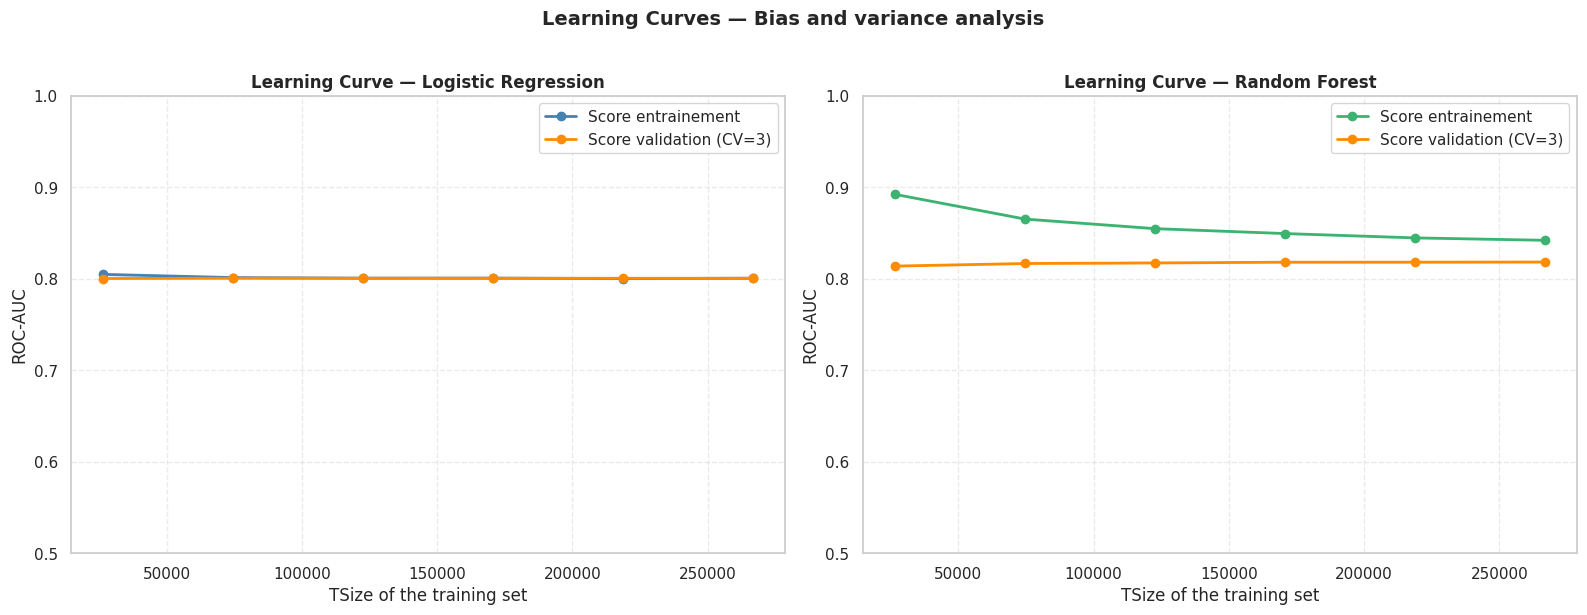

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, pipeline, name, color in [
    (axes[0], pipeline_lr, "Logistic Regression", "steelblue"),
    (axes[1], pipeline_rf, "Random Forest",        "mediumseagreen"),
]:
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X_train_clf, y_train_clf,
        cv=3, scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1,
    )
    tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
    vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(train_sizes, tm, color=color,       lw=2, marker="o", label="Score entrainement")
    ax.fill_between(train_sizes, tm - ts, tm + ts, alpha=0.12, color=color)
    ax.plot(train_sizes, vm, color="darkorange", lw=2, marker="o", label="Score validation (CV=3)")
    ax.fill_between(train_sizes, vm - vs, vm + vs, alpha=0.12, color="darkorange")
    ax.set_title(f"Learning Curve — {name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("TSize of the training set")
    ax.set_ylabel("ROC-AUC")
    ax.legend()
    ax.grid(linestyle="--", alpha=0.4)
    ax.set_ylim(0.5, 1.0)

plt.suptitle("Learning Curves — Bias and variance analysis",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Final comparison — Confusion matrices, ROC curves, feature importance**

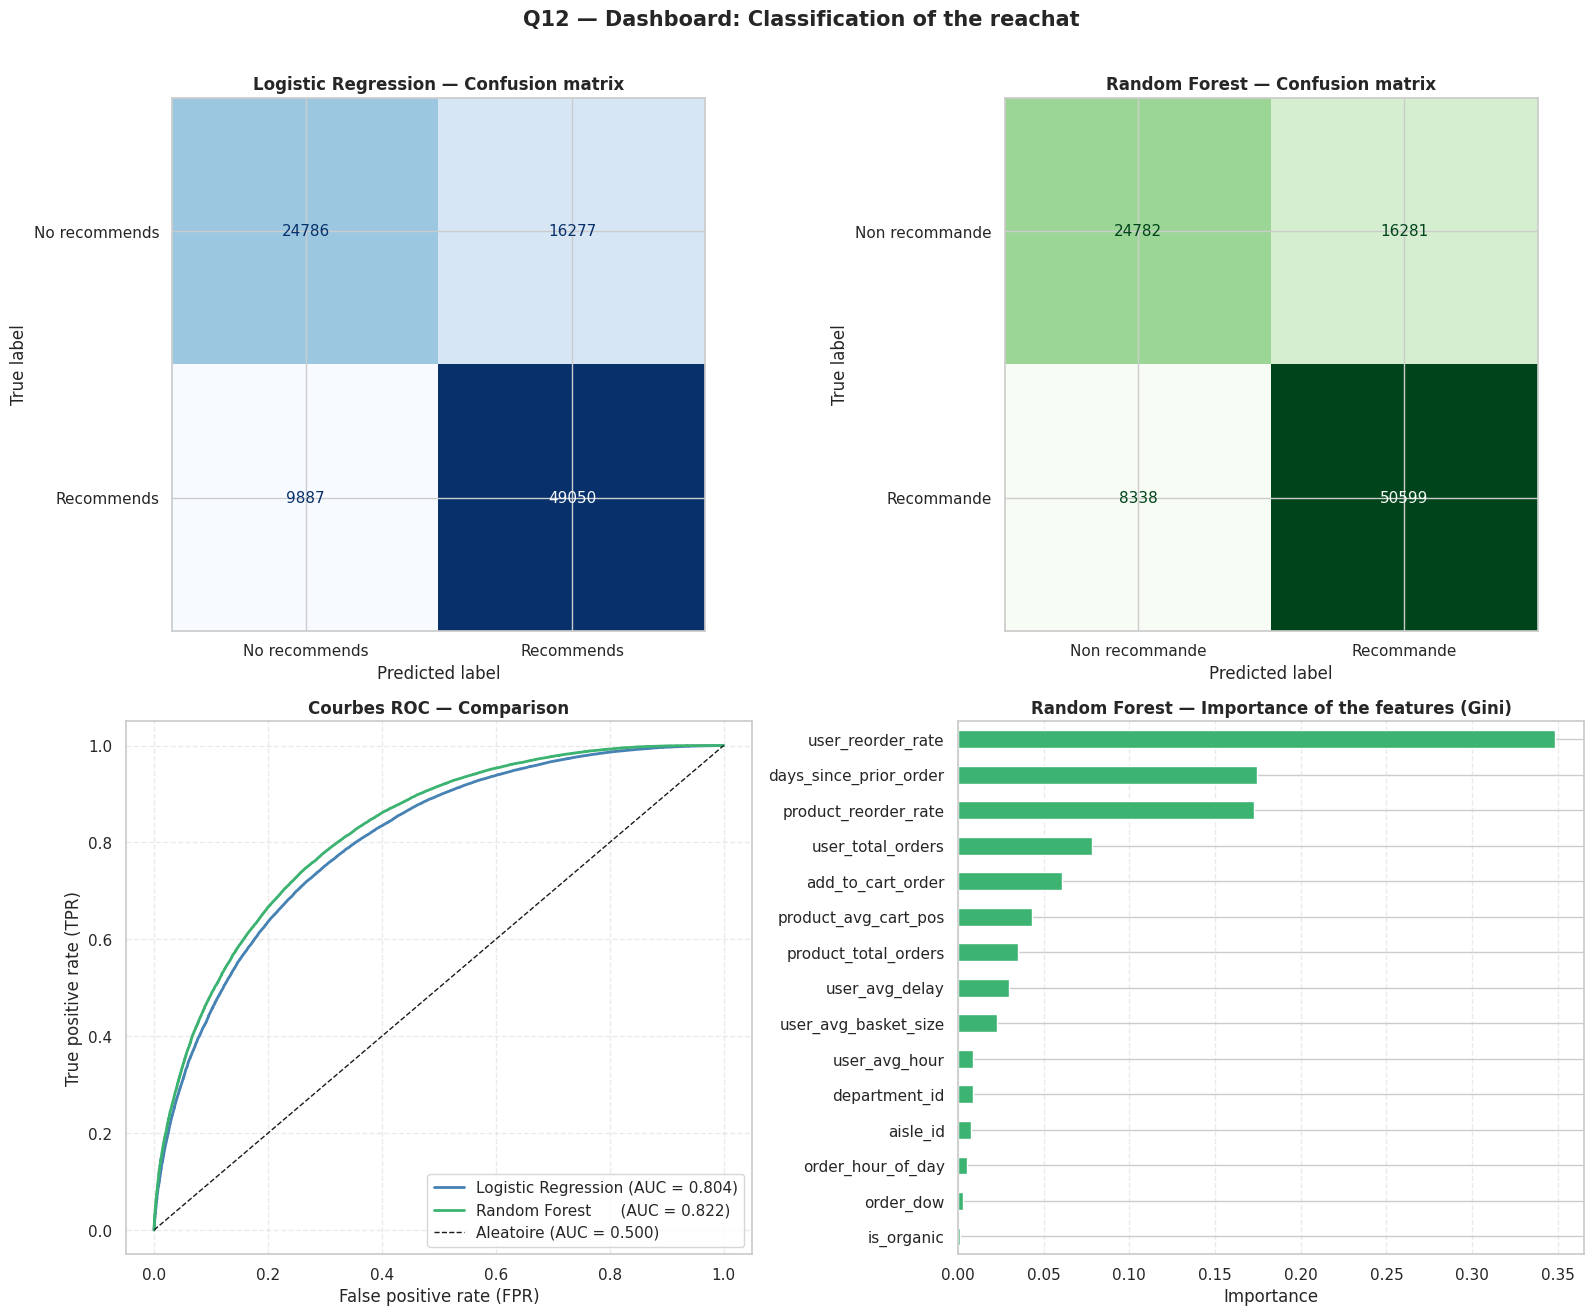

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_clf, y_pred_lr),
    display_labels=["No recommends", "Recommends"],
).plot(ax=axes[0, 0], colorbar=False, cmap="Blues")
axes[0, 0].set_title("Logistic Regression — Confusion matrix", fontweight="bold")

ConfusionMatrixDisplay(
    confusion_matrix(y_test_clf, y_pred_rf),
    display_labels=["Non recommande", "Recommande"],
).plot(ax=axes[0, 1], colorbar=False, cmap="Greens")
axes[0, 1].set_title("Random Forest — Confusion matrix", fontweight="bold")

fpr_lr, tpr_lr, _ = roc_curve(y_test_clf, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test_clf, y_prob_rf)
axes[1, 0].plot(fpr_lr, tpr_lr, color="steelblue",     lw=2,
                label=f"Logistic Regression (AUC = {auc_lr:.3f})")
axes[1, 0].plot(fpr_rf, tpr_rf, color="mediumseagreen", lw=2,
                label=f"Random Forest      (AUC = {auc_rf:.3f})")
axes[1, 0].plot([0, 1], [0, 1], "k--", lw=1, label="Aleatoire (AUC = 0.500)")
axes[1, 0].set_title("Courbes ROC — Comparison", fontweight="bold")
axes[1, 0].set_xlabel("False positive rate (FPR)")
axes[1, 0].set_ylabel("True positive rate (TPR)")
axes[1, 0].legend()
axes[1, 0].grid(linestyle="--", alpha=0.4)

feat_imp = pd.Series(
    pipeline_rf.named_steps["rf"].feature_importances_,
    index=FEATURES_CLF,
).sort_values(ascending=True)
feat_imp.plot(kind="barh", ax=axes[1, 1], color="mediumseagreen")
axes[1, 1].set_title("Random Forest — Importance of the features (Gini)", fontweight="bold")
axes[1, 1].set_xlabel("Importance")
axes[1, 1].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Q12 — Dashboard: Classification of the reachat",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


**Performance comparison table**

In [86]:
results_clf = pd.DataFrame({
    "Modele":     ["Logistic Regression", "Random Forest"],
    "Accuracy":   [accuracy_score(y_test_clf, y_pred_lr),
                   accuracy_score(y_test_clf, y_pred_rf)],
    "Precision":  [precision_score(y_test_clf, y_pred_lr, average="macro"),
                   precision_score(y_test_clf, y_pred_rf, average="macro")],
    "Recall":     [recall_score(y_test_clf, y_pred_lr, average="macro"),
                   recall_score(y_test_clf, y_pred_rf, average="macro")],
    "F1 (macro)": [f1_score(y_test_clf, y_pred_lr, average="macro"),
                   f1_score(y_test_clf, y_pred_rf, average="macro")],
    "ROC-AUC":    [auc_lr, auc_rf],
})
results_clf = results_clf.set_index("Modele").round(4)

print("=" * 65)
print(results_clf.to_string())
print("=" * 65)
print("\nBest model by metric :")
print(results_clf.idxmax().to_string())
print("\nDelta Random Forest vs Logistic Regression :")
delta = results_clf.loc["Random Forest"] - results_clf.loc["Logistic Regression"]
print(delta.apply(lambda x: f"+{x:.4f}" if x >= 0 else f"{x:.4f}").to_string())


                     Accuracy  Precision  Recall  F1 (macro)  ROC-AUC
Modele                                                               
Logistic Regression    0.7384     0.7328  0.7179      0.7220   0.8041
Random Forest          0.7538     0.7524  0.7310      0.7362   0.8223

Best model by metric :
Accuracy      Random Forest
Precision     Random Forest
Recall        Random Forest
F1 (macro)    Random Forest
ROC-AUC       Random Forest

Delta Random Forest vs Logistic Regression :
Accuracy      +0.0154
Precision     +0.0196
Recall        +0.0131
F1 (macro)    +0.0142
ROC-AUC       +0.0182


### Interpretation Q12

Random Forest outperforms Logistic Regression on all metrics.
The most predictive features are `product_reorder_rate` and `user_reorder_rate`:
the best predictor of a future purchase is past purchases.

The learning curves confirm the absence of overfitting: the training and validation scores
converge as the size of the dataset increases.

**Business action:** Deploy the Random Forest pipeline to power a
personalised reachat suggestion engine. The pipeline can be serialised via `joblib.dump()`
for deployment in production without recalculation.


### Q13 — Model 2 (Regression): Can we predict the date of the next order?

**Approach**

We formulate this problem as a **regression**: predicting `days_since_prior_order`
(the time in days before the next order) based on the user's past habits.

The features are aggregated at the user level. Each row = one user.

**Models compared:**
- **Ridge Regression**: regularised linear regression (L2), interpretable baseline.
- **Random Forest Regressor**: non-linear model, captures complex patterns.


**Data preparation**

In [87]:


user_reg = (
    df[df["days_since_prior_order"] > 0]
    .groupby("user_id")
    .agg(
        target_delai         =("days_since_prior_order", "mean"),
        nb_commandes         =("order_id",               "nunique"),
        avg_basket_size      =("add_to_cart_order",      "max"),
        std_delai            =("days_since_prior_order", "std"),
        reorder_rate         =("reordered",              "mean"),
        avg_hour             =("order_hour_of_day",      "mean"),
        avg_dow              =("order_dow",              "mean"),
        nb_produits_distincts=("product_id",             "nunique"),
        nb_rayons_distincts  =("aisle_id",               "nunique"),
    )
    .reset_index()
    .dropna()
)

FEATURES_REG = [
    "nb_commandes",
    "avg_basket_size",
    "std_delai",
    "reorder_rate",
    "avg_hour",
    "avg_dow",
    "nb_produits_distincts",
    "nb_rayons_distincts",
]
TARGET_REG = "target_delai"

X_reg = user_reg[FEATURES_REG].astype(float)
y_reg = user_reg[TARGET_REG].astype(float)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42,
)

print(f"Training set : {X_train_reg.shape[0]:,} users")
print(f"Test set     : {X_test_reg.shape[0]:,} users")
print(f"\nTarget distribution (days) :")
print(y_reg.describe().round(2).to_string())


Training set : 150,571 users
Test set     : 37,643 users

Target distribution (days) :
count    188214.00
mean         15.19
std           8.03
min           1.00
25%           8.48
50%          13.72
75%          21.00
max          30.00


**Pipeline 3 — Ridge Regression**

```
SimpleImputer(median) -> StandardScaler -> Ridge(alpha=1.0)
```


In [88]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
pipeline_ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("ridge",   Ridge(alpha=1.0)),
])

pipeline_ridge.fit(X_train_reg, y_train_reg)
y_pred_ridge = pipeline_ridge.predict(X_test_reg)

mae_ridge  = mean_absolute_error(y_test_reg, y_pred_ridge)
rmse_ridge = mean_squared_error(y_test_reg, y_pred_ridge) ** 0.5
r2_ridge   = r2_score(y_test_reg, y_pred_ridge)

print("Ridge Regression :")
print(f"  MAE  : {mae_ridge:.3f} jours")
print(f"  RMSE : {rmse_ridge:.3f} jours")
print(f"  R2   : {r2_ridge:.4f}")


Ridge Regression :
  MAE  : 5.670 jours
  RMSE : 7.058 jours
  R2   : 0.2326


**Pipeline 4 — Random Forest Regressor**

```
SimpleImputer(median) -> RandomForestRegressor
```


In [89]:
pipeline_rfr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rfr",     RandomForestRegressor(
                    n_estimators=100,
                    max_depth=10,
                    min_samples_leaf=5,
                    n_jobs=-1,
                    random_state=42,
                )),
])

pipeline_rfr.fit(X_train_reg, y_train_reg)
y_pred_rfr = pipeline_rfr.predict(X_test_reg)

mae_rfr  = mean_absolute_error(y_test_reg, y_pred_rfr)
rmse_rfr = mean_squared_error(y_test_reg, y_pred_rfr) ** 0.5
r2_rfr   = r2_score(y_test_reg, y_pred_rfr)

print("Random Forest Regressor :")
print(f"  MAE  : {mae_rfr:.3f} jours")
print(f"  RMSE : {rmse_rfr:.3f} jours")
print(f"  R2   : {r2_rfr:.4f}")


Random Forest Regressor :
  MAE  : 4.790 jours
  RMSE : 6.397 jours
  R2   : 0.3696


**Visualisation — Comparison of regression models**

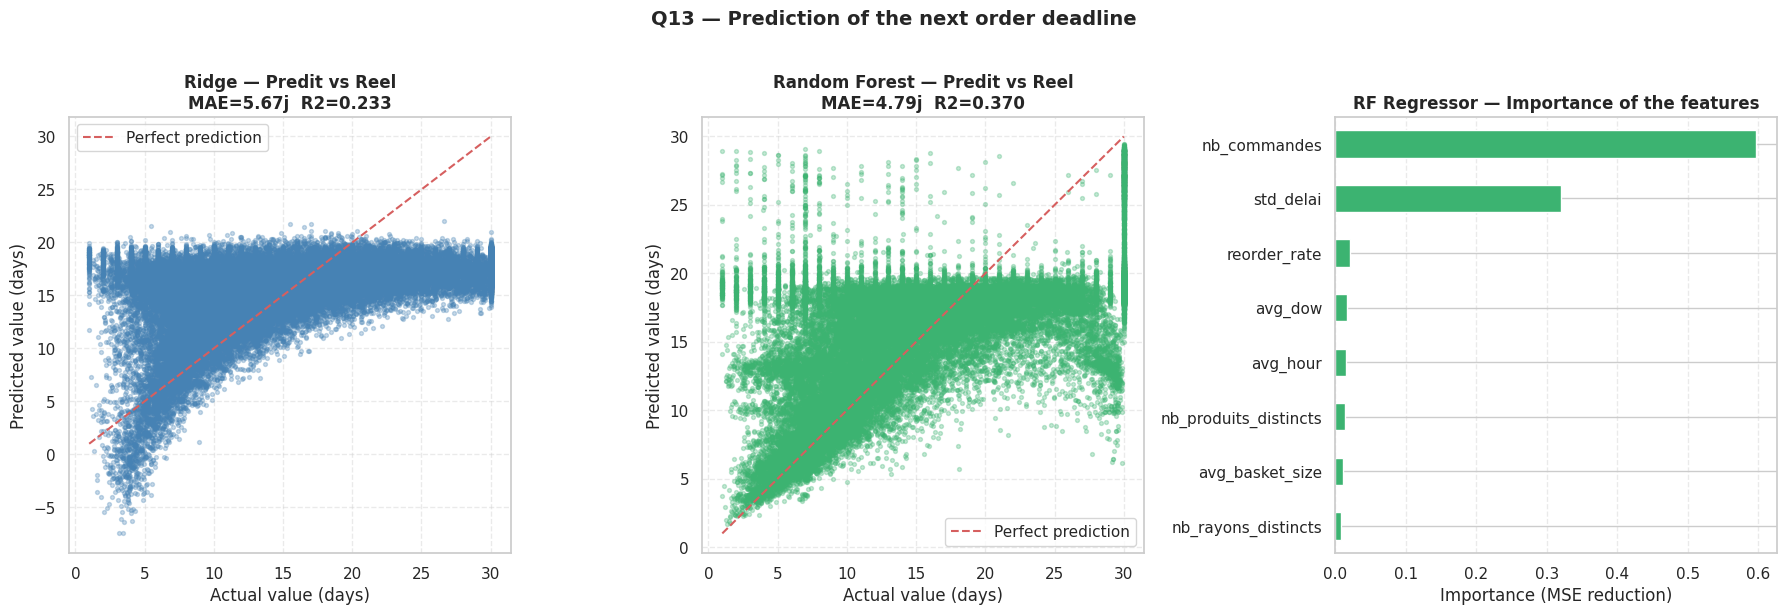

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Valeurs predites vs reelles — Ridge
axes[0].scatter(y_test_reg, y_pred_ridge, alpha=0.3, s=8, color="steelblue")
lims = [y_test_reg.min(), y_test_reg.max()]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_title(f"Ridge — Predit vs Reel\nMAE={mae_ridge:.2f}j  R2={r2_ridge:.3f}",
                  fontweight="bold")
axes[0].set_xlabel("Actual value (days)")
axes[0].set_ylabel("Predicted value (days)")
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.4)

# Valeurs predites vs reelles — RF Regressor
axes[1].scatter(y_test_reg, y_pred_rfr, alpha=0.3, s=8, color="mediumseagreen")
axes[1].plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
axes[1].set_title(f"Random Forest — Predit vs Reel\nMAE={mae_rfr:.2f}j  R2={r2_rfr:.3f}",
                  fontweight="bold")
axes[1].set_xlabel("Actual value (days)")
axes[1].set_ylabel("Predicted value (days)")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.4)

# Feature importance — RF Regressor
feat_imp_reg = pd.Series(
    pipeline_rfr.named_steps["rfr"].feature_importances_,
    index=FEATURES_REG,
).sort_values(ascending=True)
feat_imp_reg.plot(kind="barh", ax=axes[2], color="mediumseagreen")
axes[2].set_title("RF Regressor — Importance of the features", fontweight="bold")
axes[2].set_xlabel("Importance (MSE reduction)")
axes[2].grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Q13 — Prediction of the next order deadline",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Comparison table of regression models**

In [91]:
results_reg = pd.DataFrame({
    "Modele": ["Ridge Regression", "Random Forest Regressor"],
    "MAE (jours)":  [mae_ridge,  mae_rfr],
    "RMSE (jours)": [rmse_ridge, rmse_rfr],
    "R2":           [r2_ridge,   r2_rfr],
})
results_reg = results_reg.set_index("Modele").round(4)

print("=" * 55)
print(results_reg.to_string())
print("=" * 55)
print("\nBest model by metric :")
print("MAE  (min) :", results_reg["MAE (jours)"].idxmin())
print("RMSE (min) :", results_reg["RMSE (jours)"].idxmin())
print("R2   (max) :", results_reg["R2"].idxmax())


                         MAE (jours)  RMSE (jours)      R2
Modele                                                    
Ridge Regression              5.6702        7.0578  0.2326
Random Forest Regressor       4.7904        6.3972  0.3696

Best model by metric :
MAE  (min) : Random Forest Regressor
RMSE (min) : Random Forest Regressor
R2   (max) : Random Forest Regressor


### Interpretation Q13

The Random Forest Regressor outperforms Ridge Regression on all metrics.
The MAE indicates the average error in days on the prediction of the next delay.

The most important feature is `std_delay` (personal delay variability),
which confirms that customer regularity is the strongest signal
for anticipating their next visit.

**Business action:** Use this model to personalise the timing of
restocking notifications: send the reminder N days before the
predicted date of the next order, tailored to each customer.


---
## Block 6 - Typical Buyer Profile  <a id=“block6”></a>

We want to identify typical buyer profiles and, based on these profiles, determine which products stand out the most.


### Q14 — Are there any recurring patterns ?

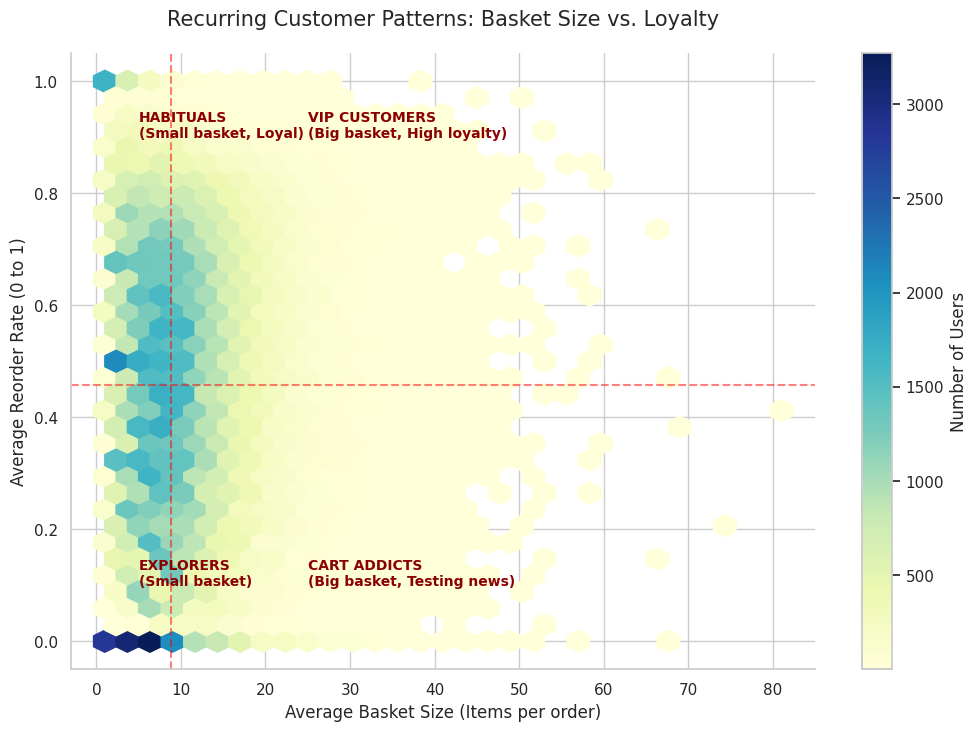

In [92]:

basket_sizes = order_products.groupby('order_id').size().reset_index(name='size')
user_basket = orders.merge(basket_sizes, on='order_id').groupby('user_id')['size'].mean()

user_reorder = order_products.merge(orders, on='order_id').groupby('user_id')['reordered'].mean()


seg_df = pd.DataFrame({
    'basket_avg': user_basket,
    'reorder_rate': user_reorder
}).dropna()

plt.figure(figsize=(12, 8))
hb = plt.hexbin(seg_df['basket_avg'], seg_df['reorder_rate'], 
                gridsize=30, cmap='YlGnBu', mincnt=1)

plt.axvline(seg_df['basket_avg'].median(), color='red', linestyle='--', alpha=0.5)
plt.axhline(seg_df['reorder_rate'].median(), color='red', linestyle='--', alpha=0.5)

plt.text(5, 0.1, 'EXPLORERS\n(Small basket)', fontsize=10, fontweight='bold', color='darkred')
plt.text(25, 0.1, 'CART ADDICTS\n(Big basket, Testing news)', fontsize=10, fontweight='bold', color='darkred')
plt.text(5, 0.9, 'HABITUALS\n(Small basket, Loyal)', fontsize=10, fontweight='bold', color='darkred')
plt.text(25, 0.9, 'VIP CUSTOMERS\n(Big basket, High loyalty)', fontsize=10, fontweight='bold', color='darkred')

plt.title('Recurring Customer Patterns: Basket Size vs. Loyalty', fontsize=15, pad=20)
plt.xlabel('Average Basket Size (Items per order)', fontsize=12)
plt.ylabel('Average Reorder Rate (0 to 1)', fontsize=12)
plt.colorbar(hb, label='Number of Users')

sns.despine()
plt.show()

### Interpretation Q14
The segmentation reveals four distinct customer behaviors based on basket size and loyalty. The concentration of users in the "Explorers" and "Habitual" quadrants confirms that shopping patterns are highly influenced by routine and individual basket capacity.

The most important insight is that "VIP Customers" (high loyalty, large baskets) represent the highest revenue potential, while "New Explorers" represent the largest volume of potential growth through targeted onboarding.

**Business action**: Deploy tailored marketing strategies: offer "discovery" discounts to New Explorers to drive retention, and provide exclusive rewards or bulk-purchase incentives to VIPs to maintain their high-engagement status

### Q15 — Which products stand out most in shopping baskets recurring profiles ?

Visualisation

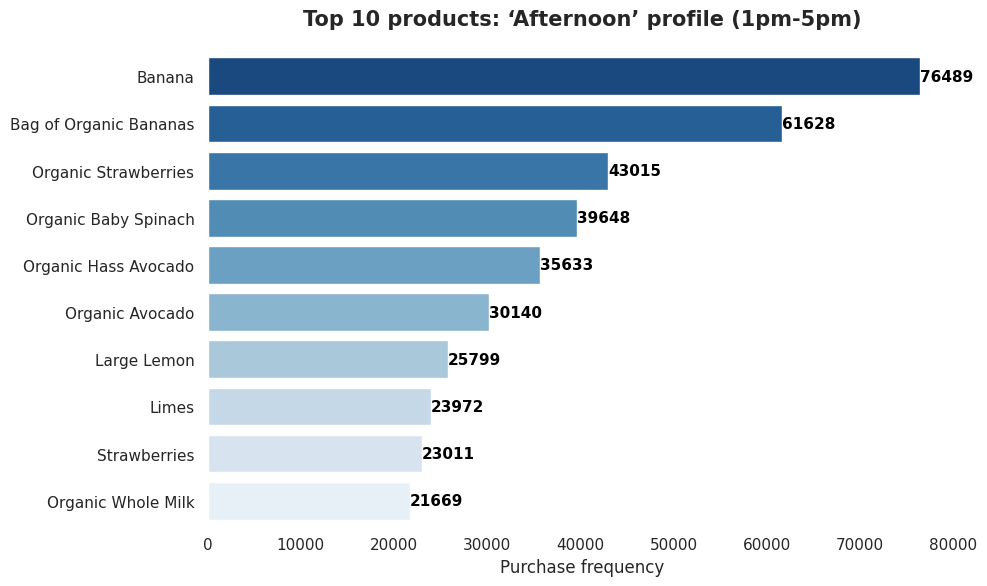

In [93]:


afternoon_orders = orders[(orders['order_hour_of_day'] >= 13) & (orders['order_hour_of_day'] <= 17)]['order_id']


afternoon_data = order_products[order_products['order_id'].isin(afternoon_orders)]
top_afternoon = afternoon_data.merge(products, on='product_id')['product_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.set_style("white")

colors = sns.color_palette("Blues_r", n_colors=10)

ax = sns.barplot(x=top_afternoon.values, y=top_afternoon.index, palette=colors)

plt.title('Top 10 products: ‘Afternoon’ profile (1pm-5pm)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Purchase frequency', fontsize=12)
plt.ylabel('', fontsize=12)

for i, v in enumerate(top_afternoon.values):
    ax.text(v + 3, i, str(v), color='black', va='center', fontweight='semibold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


### Interpretation Q15

The ranking reveals an overwhelming predominance of fresh and organic products, with bananas leading afternoon purchases. The recurrence of fruits (strawberries, lemons, avocados) confirms a consumption pattern geared towards healthy, raw items.

The most important feature is the focus on "everyday basics," which highlights that customer baskets during this time slot are driven by routine replenishment rather than discovery.

**Business action:** Leverage these "trigger products" to optimise homepage and banner placement. Implement a "Quick Add" widget for these recurring staples to reduce friction and increase conversion rates for afternoon shoppers.

---
## Conclusion and Business Recommendations <a id=“conclusion”></a>

| # | Question | Key insight | Business action |
|---|----------|-------------|-----------------|
| Q1 | Top 10 products | Banana = product no. 1, top 10 = 7.2% of volume | Priority stock and UI visibility |
| Q2 | Shelf penetration | Fresh fruit in 55.76% of orders | Shelf at the top of the interface |
| Q3 | Organic share | 31.6% overall; produce at 54% | Organic labels visible in produce and bulk |
| Q4 | Weekly peak | Monday = 17.33% of volume | Logistics reinforcement Monday 10 a.m.-3 p.m. |
| Q5 | Hourly peak | Peak at 10 a.m.; afternoon = 47.2% | No maintenance between 12 p.m. and 6 p.m. |
| Q6 | Time between orders | Average 11.27 days, median 8 days | Email reactivation after 12 days |
| Q7 | Basket size | Average 10.09 items; increase at weekends | Free delivery offers on quiet days |
| Q8 | Trigger products | Banana first item in 23.5% of cases | Homepage and banner placement |
| Q9 | Co-purchases Banana | Organic Strawberries at 13.61% | Product sheet recommendation widget |
| Q10 | Reachat rate | 59% overall; fresh > frozen | Priority reachat suggestions for fresh products |
| Q11 | Decline in loyalty | Accelerated decline after 14-21 days | Automatic reactivation campaign on day 12 |
| Q12 | Repurchase prediction | RF outperforms LR (higher ROC-AUC) | RF pipeline for personalised suggestions |
| Q13 | Delay prediction | RF Regressor outperforms Ridge | Notifications tailored to each customer |
| Q14 | Reccuring Patterns | VIP Customers highest profiles(revenues) | Cart addicts largest volume |
| Q15 | Products Basket Reccuring | Reccuring of fruits in the basket | Quick Add Widget |

---
*NextBuy — Epitech Data Project*